# US Macroeconomic Analysis Post-COVID (2021–2025)
## Federal Reserve Economic Data (FRED)

**Author:** Gaurav Kamble | **Date:** 27-04-2026  
**Data Source:** St. Louis Fed FRED API | **Tools:** Python, SQL, Power BI

---

### Abstract
This notebook conducts a comprehensive macroeconomic analysis of the  
United States economy in the post-COVID era (2021–2025), examining:

- The inflation surge and Federal Reserve tightening cycle  
- Phillips Curve breakdown and labour market resilience  
- Yield curve inversion as a recession predictor  
- Taylor Rule deviation and monetary policy assessment  
- ARIMA/SARIMA inflation forecasting  
- XGBoost predictive model for recession risk  

*Data sourced directly from the FRED API. All figures are in USD unless stated.*

In [1]:
# Install required packages
!pip install fredapi pmdarima xgboost plotly statsmodels --quiet

print("✅ All packages installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.1 MB/s eta 0:00:00
✅ All packages installed successfully


In [2]:
# Imports 
import warnings; warnings.filterwarnings('ignore')
import os, json
from fredapi import Fred
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, confusion_matrix)
from xgboost import XGBClassifier
import sqlite3
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

print("✅ All libraries imported")

✅ All libraries imported


In [3]:
# Global plot style
plt.rcParams.update({
    'figure.dpi':         130,
    'figure.facecolor':   'white',
    'axes.facecolor':     '#FAFAFA',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         '#E5E5E5',
    'grid.linewidth':     0.6,
    'axes.labelsize':     11,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'legend.fontsize':    9,
    'legend.framealpha':  0.9,
    'font.family':        'DejaVu Sans',
})

# Colour palette (consistent across all charts)
COLORS = {
    'inflation':   '#C0392B',   # red
    'unemployment':'#2471A3',   # blue
    'fed_rate':    '#1E8449',   # green
    'gdp':         '#7D3C98',   # purple
    'yield':       '#D68910',   # amber
    'neutral':     '#717D7E',   # grey
}
print("✅ Chart style configured")

✅ Chart style configured


In [4]:
# FRED API connection 

# ─── HOW TO GET YOUR FREE API KEY
# 1. Go to: https://fred.stlouisfed.org
# 2. Click "My Account" → "Create Account" (free)
# 3. After login → https://fredaccount.stlouisfed.org/apikeys
# 4. Click "Request API Key" → fill description → submit
# 5. In Kaggle: right sidebar → Add-ons → Secrets
#    Name: FRED_API_KEY  |  Value: paste your key
# ────────────────────────────────────────────────────────────

from kaggle_secrets import UserSecretsClient
API_KEY = UserSecretsClient().get_secret("FRED_API_KEY")

# If not using Kaggle Secrets, replace line above with:
# API_KEY = "paste_your_key_here_directly"

fred = Fred(api_key=API_KEY)

# Test connection
test = fred.get_series('UNRATE', observation_start='2024-01-01')
print(f"✅ FRED connected — latest unemployment: {test.iloc[-1]:.1f}%")

✅ FRED connected — latest unemployment: 4.3%


In [5]:
# Series catalogue 
SERIES = {
  # ── OUTPUT & GROWTH ──────────────────────────────────────────
  'GDPC1':           ('Real GDP (Quarterly, 2017$)',    'Output',    'Quarterly'),
  'A191RL1Q225SBEA': ('Real GDP Growth Rate YoY',       'Output',    'Quarterly'),
  'INDPRO':          ('Industrial Production Index',    'Output',    'Monthly'),
  'TCU':             ('Capacity Utilization %',         'Output',    'Monthly'),
  # ── LABOUR MARKET ────────────────────────────────────────────
  'UNRATE':          ('Unemployment Rate %',            'Labour',    'Monthly'),
  'PAYEMS':          ('Nonfarm Payrolls (000s)',         'Labour',    'Monthly'),
  'CIVPART':         ('Labour Force Participation %',   'Labour',    'Monthly'),
  'JTSJOL':          ('JOLTS Job Openings (000s)',       'Labour',    'Monthly'),
  'ICSA':            ('Initial Jobless Claims',         'Labour',    'Weekly'),
  # ── INFLATION & PRICES ───────────────────────────────────────
  'CPIAUCSL':        ('CPI All Items (Index)',          'Prices',    'Monthly'),
  'CPILFESL':        ('Core CPI ex Food+Energy',       'Prices',    'Monthly'),
  'PCEPI':           ('PCE Inflation Index',            'Prices',    'Monthly'),
  'PCEPILFE':        ('Core PCE (Fed Preferred)',       'Prices',    'Monthly'),
  'PPIACO':          ('Producer Price Index PPI',      'Prices',    'Monthly'),
  # ── MONETARY POLICY ──────────────────────────────────────────
  'FEDFUNDS':        ('Federal Funds Rate %',           'Monetary',  'Monthly'),
  'GS10':            ('10-Year Treasury Yield %',       'Monetary',  'Monthly'),
  'GS2':             ('2-Year Treasury Yield %',        'Monetary',  'Monthly'),
  'M2SL':            ('M2 Money Supply (Bil USD)',      'Monetary',  'Monthly'),
  # ── FINANCIAL CONDITIONS ─────────────────────────────────────
  'VIXCLS':          ('VIX Volatility Index',          'Financial', 'Daily'),
  'MORTGAGE30US':    ('30-Year Mortgage Rate %',        'Financial', 'Weekly'),
  'UMCSENT':         ('Univ of Michigan Consumer Sent', 'Financial', 'Monthly'),
  # ── LEADING INDICATORS ───────────────────────────────────────
  'USSLIND':         ('Conference Board LEI',          'Leading',   'Monthly'),
  'HOUST':           ('Housing Starts (000s)',          'Leading',   'Monthly'),
  'RSXFS':           ('Retail Sales ex Food (Mil USD)', 'Leading',   'Monthly'),
  'RPI':             ('Real Personal Income (Bil USD)', 'Leading',   'Monthly'),
}
print(f"✅ Catalogue ready — {len(SERIES)} series defined")

✅ Catalogue ready — 25 series defined


In [6]:
# Pull data from FRED API 
START = '2021-01-01'
END   = '2025-12-31'

raw_data = {}
failed   = []

for i, (sid, (name, cat, freq)) in enumerate(SERIES.items()):
    try:
        s = fred.get_series(sid, observation_start=START, observation_end=END)
        raw_data[sid] = s
        status = "OK  " + sid.ljust(18) + str(len(s)).rjust(5) + " obs  — " + name
        print("[" + str(i+1).rjust(2) + "/25] " + status)
    except Exception as e:
        failed.append(sid)
        print("[" + str(i+1).rjust(2) + "/25] FAIL " + sid + " — " + str(e))

print("")
print("Downloaded " + str(len(raw_data)) + "/25 series")
if failed:
    print("Failed series: " + str(failed))

[ 1/25] OK  GDPC1                20 obs  — Real GDP (Quarterly, 2017$)
[ 2/25] OK  A191RL1Q225SBEA      20 obs  — Real GDP Growth Rate YoY
[ 3/25] OK  INDPRO               60 obs  — Industrial Production Index
[ 4/25] OK  TCU                  60 obs  — Capacity Utilization %
[ 5/25] OK  UNRATE               60 obs  — Unemployment Rate %
[ 6/25] OK  PAYEMS               60 obs  — Nonfarm Payrolls (000s)
[ 7/25] OK  CIVPART              60 obs  — Labour Force Participation %
[ 8/25] OK  JTSJOL               60 obs  — JOLTS Job Openings (000s)
[ 9/25] OK  ICSA                261 obs  — Initial Jobless Claims
[10/25] OK  CPIAUCSL             60 obs  — CPI All Items (Index)
[11/25] OK  CPILFESL             60 obs  — Core CPI ex Food+Energy
[12/25] OK  PCEPI                60 obs  — PCE Inflation Index
[13/25] OK  PCEPILFE             60 obs  — Core PCE (Fed Preferred)
[14/25] OK  PPIACO               60 obs  — Producer Price Index PPI
[15/25] OK  FEDFUNDS             60 obs  — Federal Funds

In [7]:
# Retry failed series with delay 
import time

# These 4 failed due to timeout — retry them one by one with a pause
to_retry = ['PAYEMS', 'CIVPART', 'CPIAUCSL', 'M2SL']

for sid in to_retry:
    for attempt in range(1, 4):          # try up to 3 times each
        try:
            time.sleep(3)                # wait 3 seconds before each call
            s = fred.get_series(sid, observation_start=START, observation_end=END)
            raw_data[sid] = s
            name = SERIES[sid][0]
            print("OK  " + sid + " (" + str(len(s)) + " obs)  — " + name)
            break                        # success — move to next series
        except Exception as e:
            print("Attempt " + str(attempt) + " failed for " + sid + ": " + str(e))
            if attempt == 3:
                print("GIVING UP on " + sid + " — will use fallback below")

# ── Verify all 25 are now loaded ────────────────────────────────
print("")
print("Total series loaded: " + str(len(raw_data)) + " / 25")

still_missing = [s for s in SERIES if s not in raw_data]
if still_missing:
    print("Still missing: " + str(still_missing))
    print("Running fallback for missing series...")

    # Fallback: if a series truly won't load, fill with NaN
    # so Cell 9 (the merge) doesn't crash
    for sid in still_missing:
        import pandas as pd
        raw_data[sid] = pd.Series(dtype=float, name=sid)
        print("  Filled " + sid + " with empty series (NaN)")
else:
    print("All 25 series loaded successfully — proceed to the next Cell")

OK  PAYEMS (60 obs)  — Nonfarm Payrolls (000s)
OK  CIVPART (60 obs)  — Labour Force Participation %
OK  CPIAUCSL (60 obs)  — CPI All Items (Index)
OK  M2SL (60 obs)  — M2 Money Supply (Bil USD)

Total series loaded: 25 / 25
All 25 series loaded successfully — proceed to the next Cell


In [8]:
# Merge + derive variables 
monthly_ids = [s for s,(n,c,f) in SERIES.items() if f in ('Monthly','Weekly','Daily')]

dfs = []
for sid in monthly_ids:
    if sid in raw_data:
        df_s = raw_data[sid].rename(sid)
        df_s.index = pd.to_datetime(df_s.index)
        df_s = df_s.resample('MS').last()     # month-start
        dfs.append(df_s)

master = pd.concat(dfs, axis=1)
master.index.name = 'date'

# ── DERIVED VARIABLES (the economically meaningful ones) ─────
master['CPI_YOY']       = master['CPIAUCSL'].pct_change(12)*100
master['CORE_CPI_YOY']  = master['CPILFESL'].pct_change(12)*100
master['PCE_YOY']       = master['PCEPI'].pct_change(12)*100
master['CORE_PCE_YOY']  = master['PCEPILFE'].pct_change(12)*100
master['PPI_YOY']       = master['PPIACO'].pct_change(12)*100
master['YIELD_SPREAD']  = master['GS10'] - master['GS2']
master['REAL_FEDFUNDS'] = master['FEDFUNDS'] - master['CORE_CPI_YOY']
master['M2_YOY']        = master['M2SL'].pct_change(12)*100
master['PAYROLL_MOM']   = master['PAYEMS'].diff()
master['INDPRO_YOY']    = master['INDPRO'].pct_change(12)*100

master = master[master.index >= '2021-01-01']

print(f"✅ Master dataset: {master.shape[0]} rows × {master.shape[1]} columns")
print(f"   Date range: {master.index[0].date()} → {master.index[-1].date()}")
master.tail(3)

✅ Master dataset: 60 rows × 33 columns
   Date range: 2021-01-01 → 2025-12-01


,INDPRO,TCU,UNRATE,PAYEMS,CIVPART,JTSJOL,ICSA,CPIAUCSL,CPILFESL,PCEPI,...,CPI_YOY,CORE_CPI_YOY,PCE_YOY,CORE_PCE_YOY,PPI_YOY,YIELD_SPREAD,REAL_FEDFUNDS,M2_YOY,PAYROLL_MOM,INDPRO_YOY
date,,,,,,,,,,,,,,,,,,,,,
2025-10-01,101.2195,75.6194,NaN,158408.0,NaN,7170.0,221000.0,NaN,NaN,127.871,...,2.729136,2.700082,2.712581,2.754538,2.967429,0.54,1.389918,4.280913,-140.0,1.759333
2025-11-01,101.0810,75.4249,4.5,158449.0,62.5,6846.0,216000.0,325.063,331.043,128.152,...,2.696444,2.599045,2.820190,2.829093,3.437054,0.54,1.280955,3.847158,41.0,1.801244
2025-12-01,101.6113,75.7296,4.4,158432.0,62.4,6550.0,203000.0,326.031,331.814,128.576,...,2.653304,2.646485,2.878084,2.971110,3.127577,0.64,1.073515,4.038462,-17.0,1.279811


In [9]:
# SQLite database + analytical SQL queries ───────────
conn = sqlite3.connect(':memory:')
master.reset_index().to_sql('macro', conn, if_exists='replace', index=False)

# ── Query 1: Annual macro summary ───────────────────────────────
q1 = pd.read_sql("""
    SELECT
        strftime('%Y', date)          AS year,
        ROUND(AVG(FEDFUNDS), 2)       AS avg_fed_rate,
        ROUND(AVG(CPI_YOY), 2)        AS avg_inflation,
        ROUND(AVG(UNRATE), 2)         AS avg_unemployment,
        ROUND(AVG(YIELD_SPREAD), 2)   AS avg_yield_spread,
        ROUND(AVG(REAL_FEDFUNDS), 2)  AS avg_real_rate,
        CASE
            WHEN AVG(REAL_FEDFUNDS) < 0 THEN 'Accommodative'
            ELSE 'Restrictive'
        END AS policy_stance
    FROM macro
    GROUP BY year
    ORDER BY year
""", conn)

print("=== Annual Macro Summary ===")
print(q1.to_string(index=False))

# ── Query 2: Yield curve inversion periods ───────────────────────
q2 = pd.read_sql("""
    SELECT date, GS10, GS2, YIELD_SPREAD
    FROM macro
    WHERE YIELD_SPREAD < 0
    ORDER BY date
""", conn)

print("")
print("Yield curve inversion periods: " + str(len(q2)) + " months")
print(q2[['date','GS10','GS2','YIELD_SPREAD']].to_string(index=False))

# ── Query 3: Months where inflation exceeded 5% ──────────────────
q3 = pd.read_sql("""
    SELECT date, CPI_YOY, CORE_CPI_YOY, FEDFUNDS, UNRATE
    FROM macro
    WHERE CPI_YOY > 5
    ORDER BY CPI_YOY DESC
""", conn)

print("")
print("Months with CPI > 5%: " + str(len(q3)))
print(q3.to_string(index=False))

=== Annual Macro Summary ===
year  avg_fed_rate  avg_inflation  avg_unemployment  avg_yield_spread  avg_real_rate policy_stance
2021          0.08            NaN              5.35              1.18            NaN   Restrictive
2022          1.68           8.00              3.65             -0.03          -4.47 Accommodative
2023          5.02           4.15              3.63             -0.63           0.23   Restrictive
2024          5.14           2.95              4.03             -0.16           1.70   Restrictive
2025          4.21           2.70              4.26              0.48           1.31   Restrictive

Yield curve inversion periods: 26 months
               date  GS10  GS2  YIELD_SPREAD
2022-07-01 00:00:00  2.90 3.04         -0.14
2022-08-01 00:00:00  2.90 3.25         -0.35
2022-09-01 00:00:00  3.52 3.86         -0.34
2022-10-01 00:00:00  3.98 4.38         -0.40
2022-11-01 00:00:00  3.89 4.50         -0.61
2022-12-01 00:00:00  3.62 4.29         -0.67
2023-01-01 00:00:00 

---
<a id="4"></a>
## Exploratory Data Analysis

> *"Before building any model, understand your data."*

**Objective:** Understand the shape, distribution, and trajectory of all 25 indicators  
across the post-COVID period. Identify structural breaks, outliers, and narrative.

In [10]:
# Summary statistics ────────────────────────────────
KEY_VARS = ['UNRATE','CPI_YOY','CORE_CPI_YOY','FEDFUNDS',
            'REAL_FEDFUNDS','GS10','GS2','YIELD_SPREAD',
            'M2_YOY','PAYROLL_MOM','UMCSENT','USSLIND']

stats_df = master[KEY_VARS].describe().T.round(2)
stats_df.columns = ['Count','Mean','Std','Min','Q25','Q50','Q75','Max']

# Highlight min and max
styled = (stats_df.style
    .background_gradient(subset=['Mean'], cmap='RdYlGn_r')
    .background_gradient(subset=['Std'],  cmap='YlOrRd')
    .format("{:.2f}")
    .set_caption("Table 1 — Descriptive Statistics (Jan 2021 – Dec 2024)"))
styled

,Count,Mean,Std,Min,Q25,Q50,Q75,Max
UNRATE,59.00,4.18,0.76,3.40,3.65,4.00,4.30,6.40
CPI_YOY,48.00,4.45,2.25,2.33,2.79,3.25,6.35,8.98
CORE_CPI_YOY,48.00,4.32,1.33,2.60,3.23,3.89,5.60,6.62
FEDFUNDS,60.00,3.23,2.13,0.06,0.30,4.33,5.09,5.33
REAL_FEDFUNDS,48.00,-0.31,2.65,-6.38,-1.30,1.20,1.48,2.10
GS10,60.00,3.37,1.15,1.08,2.60,3.88,4.26,4.80
GS2,60.00,3.20,1.68,0.12,2.38,3.90,4.40,5.07
YIELD_SPREAD,60.00,0.17,0.67,-0.93,-0.38,0.15,0.55,1.48
M2_YOY,48.00,1.78,4.02,-4.63,-1.80,2.58,4.06,11.72
PAYROLL_MOM,59.00,263.88,254.29,-140.00,72.00,206.00,395.50,942.00


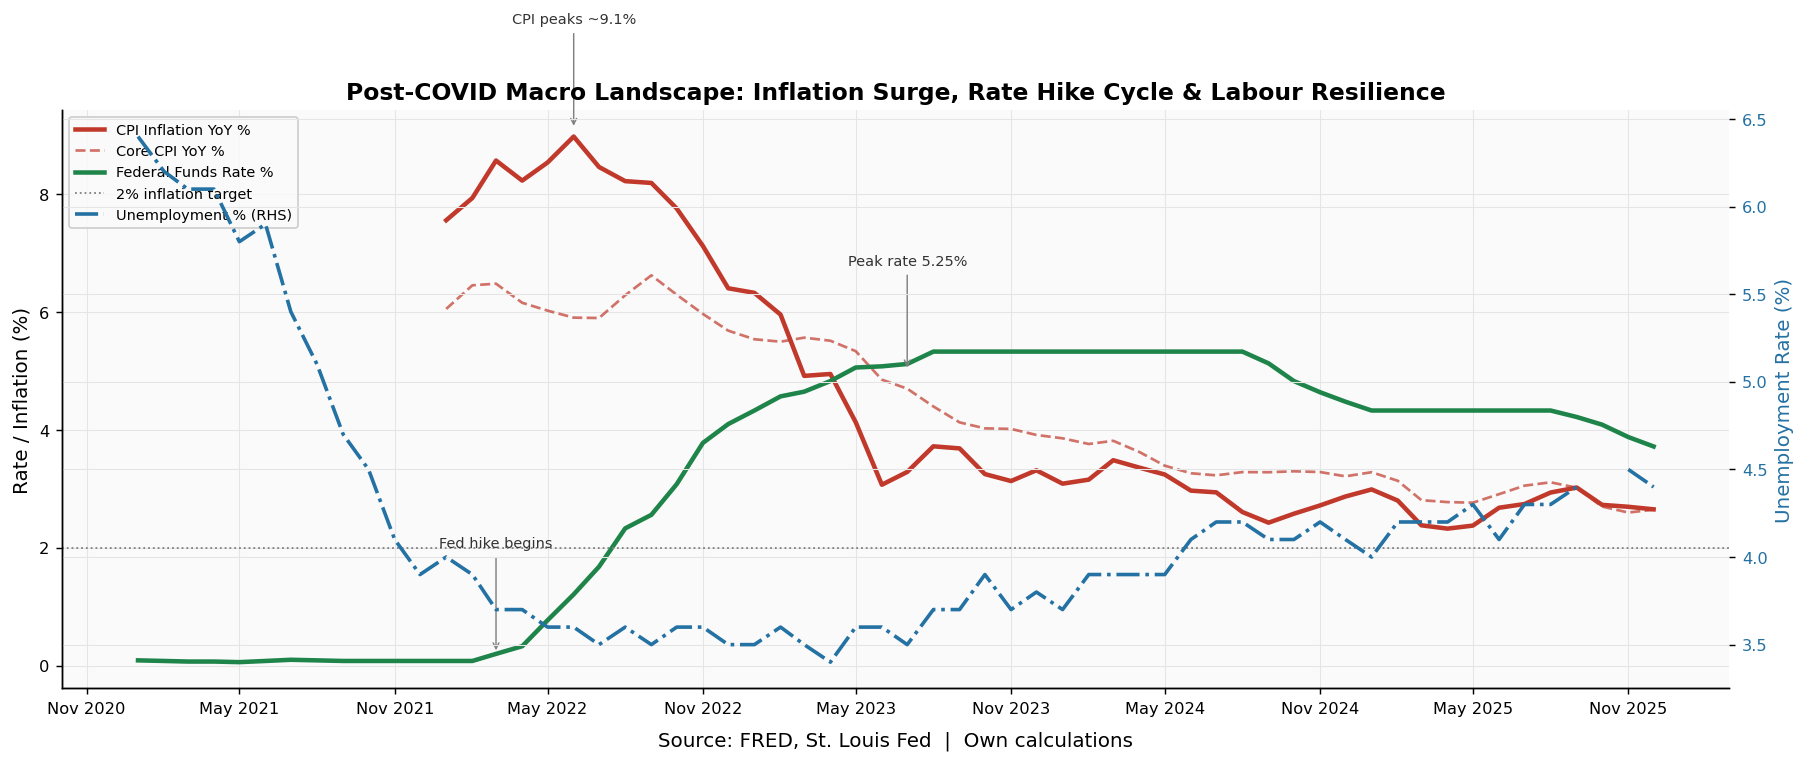

In [11]:
# The Big 3 chart ────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# Left axis — inflation and fed rate
ax1.plot(master.index, master['CPI_YOY'],
         color=COLORS['inflation'], lw=2.5, label='CPI Inflation YoY %')
ax1.plot(master.index, master['CORE_CPI_YOY'],
         color=COLORS['inflation'], lw=1.5, linestyle='--',
         alpha=0.7, label='Core CPI YoY %')
ax1.plot(master.index, master['FEDFUNDS'],
         color=COLORS['fed_rate'], lw=2.5, label='Federal Funds Rate %')
ax1.axhline(2, color='grey', lw=1, ls=':', label='2% inflation target')

# Right axis — unemployment
ax2.plot(master.index, master['UNRATE'],
         color=COLORS['unemployment'], lw=2, linestyle='-.',
         label='Unemployment % (RHS)')
ax2.set_ylabel('Unemployment Rate (%)', color=COLORS['unemployment'])
ax2.tick_params(axis='y', labelcolor=COLORS['unemployment'])

# Key event annotations (no newlines inside strings)
events = {
    '2022-03-01': ('Fed hike begins', 0.2),
    '2022-06-01': ('CPI peaks ~9.1%',  9.1),
    '2023-07-01': ('Peak rate 5.25%',  5.0),
}
for date_str, (label, y) in events.items():
    ax1.annotate(
        label,
        xy=(pd.Timestamp(date_str), y),
        xytext=(pd.Timestamp(date_str), y + 1.8),
        fontsize=8, ha='center',
        arrowprops=dict(arrowstyle='->', color='grey', lw=0.8),
        color='#333'
    )

ax1.set_title(
    'Post-COVID Macro Landscape: Inflation Surge, Rate Hike Cycle & Labour Resilience'
)
ax1.set_ylabel('Rate / Inflation (%)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

ax1.set_xlabel('Source: FRED, St. Louis Fed  |  Own calculations', labelpad=8)
plt.tight_layout()
plt.savefig('fig1_big3.png', dpi=150, bbox_inches='tight')
plt.show()

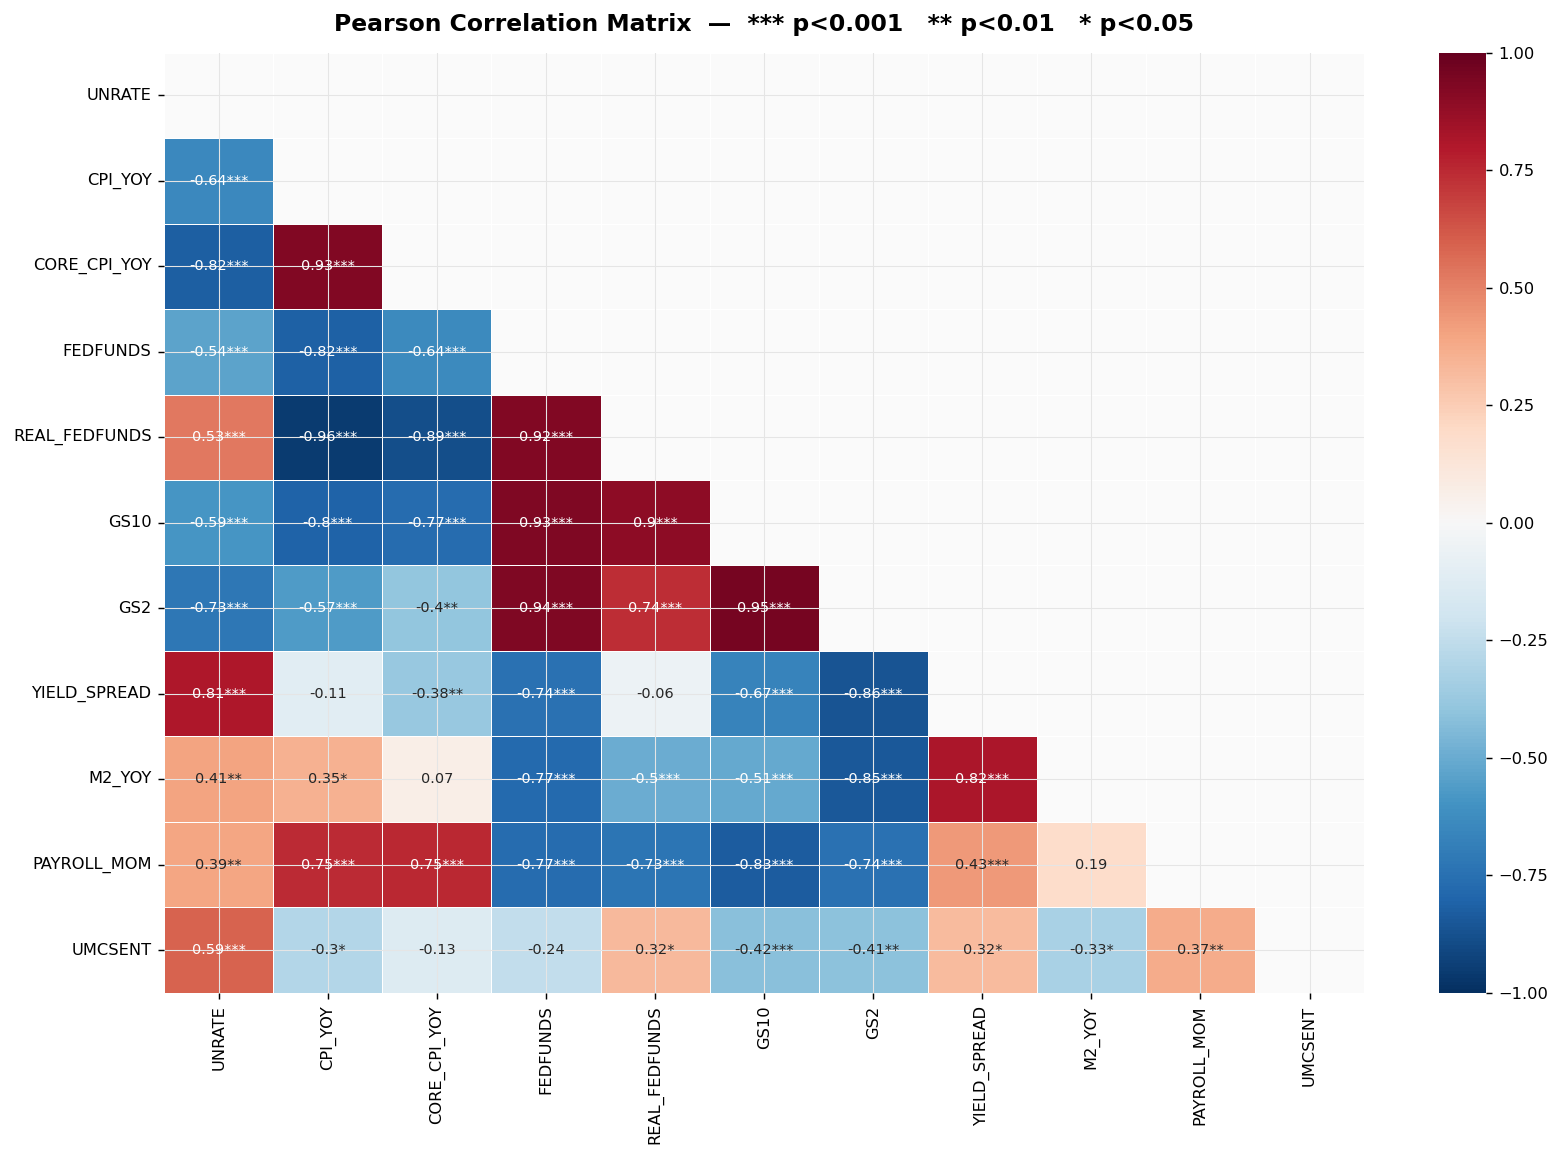

Top 10 strongest correlations:
  REAL_FEDFUNDS vs CPI_YOY:  r=-0.958  ***
  GS2 vs GS10:  r=0.955  ***
  GS2 vs FEDFUNDS:  r=0.937  ***
  GS10 vs FEDFUNDS:  r=0.93  ***
  CORE_CPI_YOY vs CPI_YOY:  r=0.927  ***
  REAL_FEDFUNDS vs FEDFUNDS:  r=0.922  ***
  GS10 vs REAL_FEDFUNDS:  r=0.898  ***
  REAL_FEDFUNDS vs CORE_CPI_YOY:  r=-0.886  ***
  YIELD_SPREAD vs GS2:  r=-0.86  ***
  M2_YOY vs GS2:  r=-0.846  ***


In [12]:
# Correlation heatmap with significance stars ─────────

KEY_VARS = [v for v in [
    'UNRATE', 'CPI_YOY', 'CORE_CPI_YOY', 'FEDFUNDS',
    'REAL_FEDFUNDS', 'GS10', 'GS2', 'YIELD_SPREAD',
    'M2_YOY', 'PAYROLL_MOM', 'UMCSENT', 'USSLIND'
] if v in master.columns and master[v].notna().sum() > 5]

corr = master[KEY_VARS].corr(method='pearson')

# ── Build p-value matrix (scipy 1.9+ compatible) ─────────────────
# pearsonr now returns a PearsonRResult object — use .pvalue attribute
pval = pd.DataFrame(np.ones((len(KEY_VARS), len(KEY_VARS))),
                    index=KEY_VARS, columns=KEY_VARS)

for i, v1 in enumerate(KEY_VARS):
    for j, v2 in enumerate(KEY_VARS):
        if i == j:
            pval.loc[v1, v2] = 1.0
        else:
            d = master[[v1, v2]].dropna()
            if len(d) > 3:
                result = stats.pearsonr(d[v1].values, d[v2].values)
                # .pvalue works on both old tuple and new object
                p = result.pvalue if hasattr(result, 'pvalue') else result[1]
                pval.loc[v1, v2] = float(p)

# ── Significance stars function ──────────────────────────────────
def stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

# ── Build annotation matrix ──────────────────────────────────────
annot = pd.DataFrame('', index=KEY_VARS, columns=KEY_VARS)
for v1 in KEY_VARS:
    for v2 in KEY_VARS:
        r = corr.loc[v1, v2]
        p = pval.loc[v1, v2]
        annot.loc[v1, v2] = str(round(r, 2)) + stars(p)

# ── Plot ─────────────────────────────────────────────────────────
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(
    corr,
    annot=annot,
    fmt='',
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title(
    'Pearson Correlation Matrix  —  *** p<0.001   ** p<0.01   * p<0.05',
    pad=12
)
plt.tight_layout()
plt.savefig('fig2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print top 5 strongest correlations ───────────────────────────
print("Top 10 strongest correlations:")
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
                  .stack()
                  .abs()
                  .sort_values(ascending=False))
for (v1, v2), val in corr_pairs.head(10).items():
    r   = corr.loc[v1, v2]
    p   = pval.loc[v1, v2]
    sig = stars(p)
    print("  " + v1 + " vs " + v2 + ":  r=" + str(round(r, 3)) + "  " + sig)

In [13]:
# Multiple OLS Regression — CPI inflation determinants

# Lag predictors to respect causality (policy affects inflation with a delay)
master['FEDFUNDS_L6']  = master['FEDFUNDS'].shift(6)
master['M2_YOY_L6']    = master['M2_YOY'].shift(6)   if 'M2_YOY'   in master.columns else np.nan
master['FEDFUNDS_L12'] = master['FEDFUNDS'].shift(12)
master['M2_YOY_L12']   = master['M2_YOY'].shift(12)  if 'M2_YOY'   in master.columns else np.nan

# Build list of available regressors (skip any that are all-NaN)
candidate_regressors = [
    'FEDFUNDS_L6',
    'M2_YOY_L6',
    'UNRATE',
    'YIELD_SPREAD',
    'INDPRO_YOY',
]
regressors = [c for c in candidate_regressors
              if c in master.columns and master[c].notna().sum() > 10]

reg_cols  = ['CPI_YOY'] + regressors
reg_data  = master[reg_cols].dropna()

print("Rows used in regression: " + str(len(reg_data)))
print("Regressors: " + str(regressors))

X = sm.add_constant(reg_data[regressors])
y = reg_data['CPI_YOY']

# HC3 = heteroscedasticity-robust standard errors (standard in macro work)
model = sm.OLS(y, X).fit(cov_type='HC3')

print(model.summary())

# Plain-string interpretation block (no f-strings)
r2_pct   = round(model.rsquared * 100, 1)
sig_flag = 'significant' if model.f_pvalue < 0.05 else 'NOT significant'
aic_val  = round(model.aic, 2)
bic_val  = round(model.bic, 2)

print("")
print("=== Plain-English Interpretation ===")
print("R-squared  : " + str(r2_pct) + "% of inflation variance explained by the model")
print("F-stat     : model is " + sig_flag + " (p=" + str(round(model.f_pvalue, 4)) + ")")
print("AIC        : " + str(aic_val) + "  |  BIC: " + str(bic_val))
print("")
print("Coefficient signs:")
for var, coef in model.params.items():
    if var == 'const':
        continue
    direction = 'POSITIVE' if coef > 0 else 'NEGATIVE'
    pv        = model.pvalues[var]
    sig       = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else '(not sig)'))
    print("  " + var + ": " + direction + "  coef=" + str(round(coef, 3)) + "  " + sig)

Rows used in regression: 41
Regressors: ['FEDFUNDS_L6', 'M2_YOY_L6', 'UNRATE', 'YIELD_SPREAD', 'INDPRO_YOY']
                            OLS Regression Results                            
Dep. Variable:                CPI_YOY   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     94.82
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           2.48e-19
Time:                        18:24:10   Log-Likelihood:                -22.998
No. Observations:                  41   AIC:                             58.00
Df Residuals:                      35   BIC:                             68.28
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------

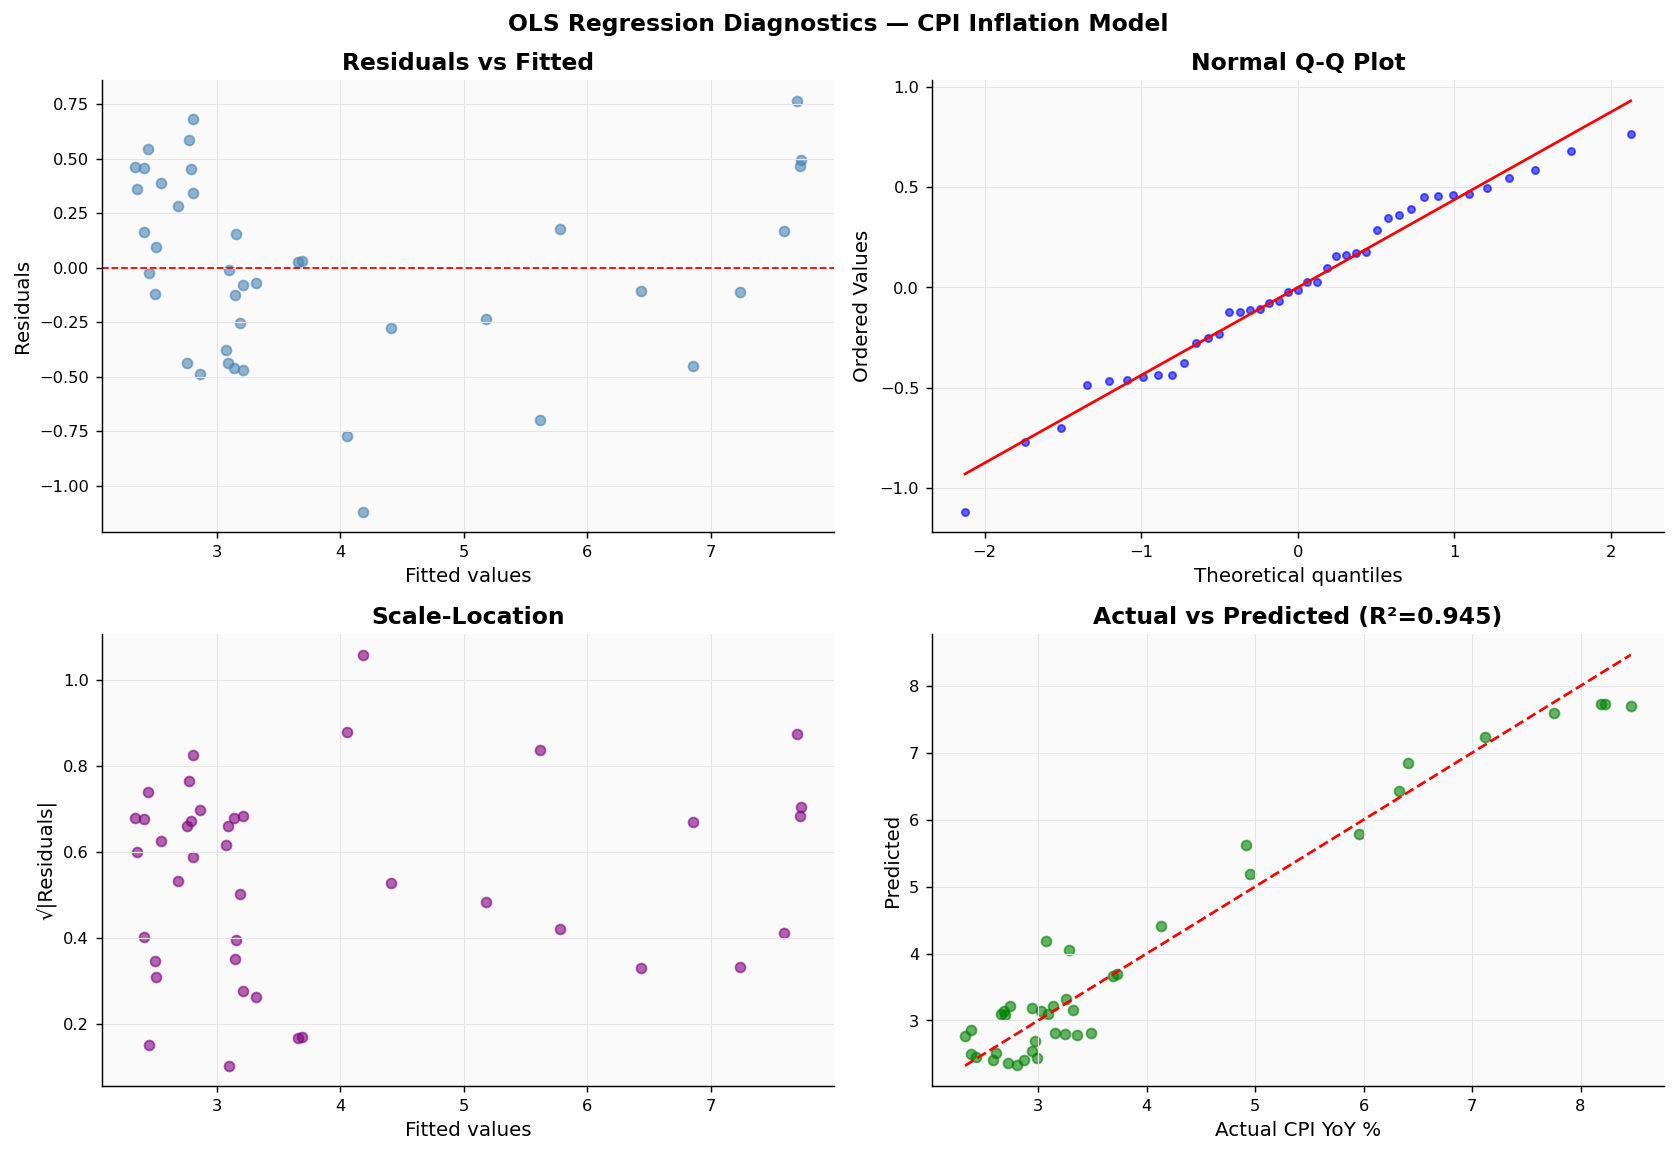

In [14]:
# Regression diagnostics ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('OLS Regression Diagnostics — CPI Inflation Model', fontsize=13, fontweight='bold')

resid = model.resid
fitted = model.fittedvalues

# 1: Residuals vs Fitted
axes[0,0].scatter(fitted, resid, alpha=0.6, s=30, color='steelblue')
axes[0,0].axhline(0, color='red', lw=1, ls='--')
axes[0,0].set(xlabel='Fitted values', ylabel='Residuals', title='Residuals vs Fitted')

# 2: Q-Q Plot
stats.probplot(resid, dist='norm', plot=axes[0,1])
axes[0,1].set_title('Normal Q-Q Plot')
axes[0,1].get_lines()[0].set(markersize=4, alpha=0.6)

# 3: Scale-Location
axes[1,0].scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.6, s=30, color='purple')
axes[1,0].set(xlabel='Fitted values', ylabel='√|Residuals|', title='Scale-Location')

# 4: Actual vs Predicted
axes[1,1].scatter(y, fitted, alpha=0.6, s=30, color='green')
mn, mx = min(y.min(), fitted.min()), max(y.max(), fitted.max())
axes[1,1].plot([mn,mx],[mn,mx], 'r--', lw=1.5)
axes[1,1].set(xlabel='Actual CPI YoY %', ylabel='Predicted', title=f'Actual vs Predicted (R²={model.rsquared:.3f})')

plt.tight_layout()
plt.savefig('fig3_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

Estimated NAIRU (inflation = 2%): 4.41%


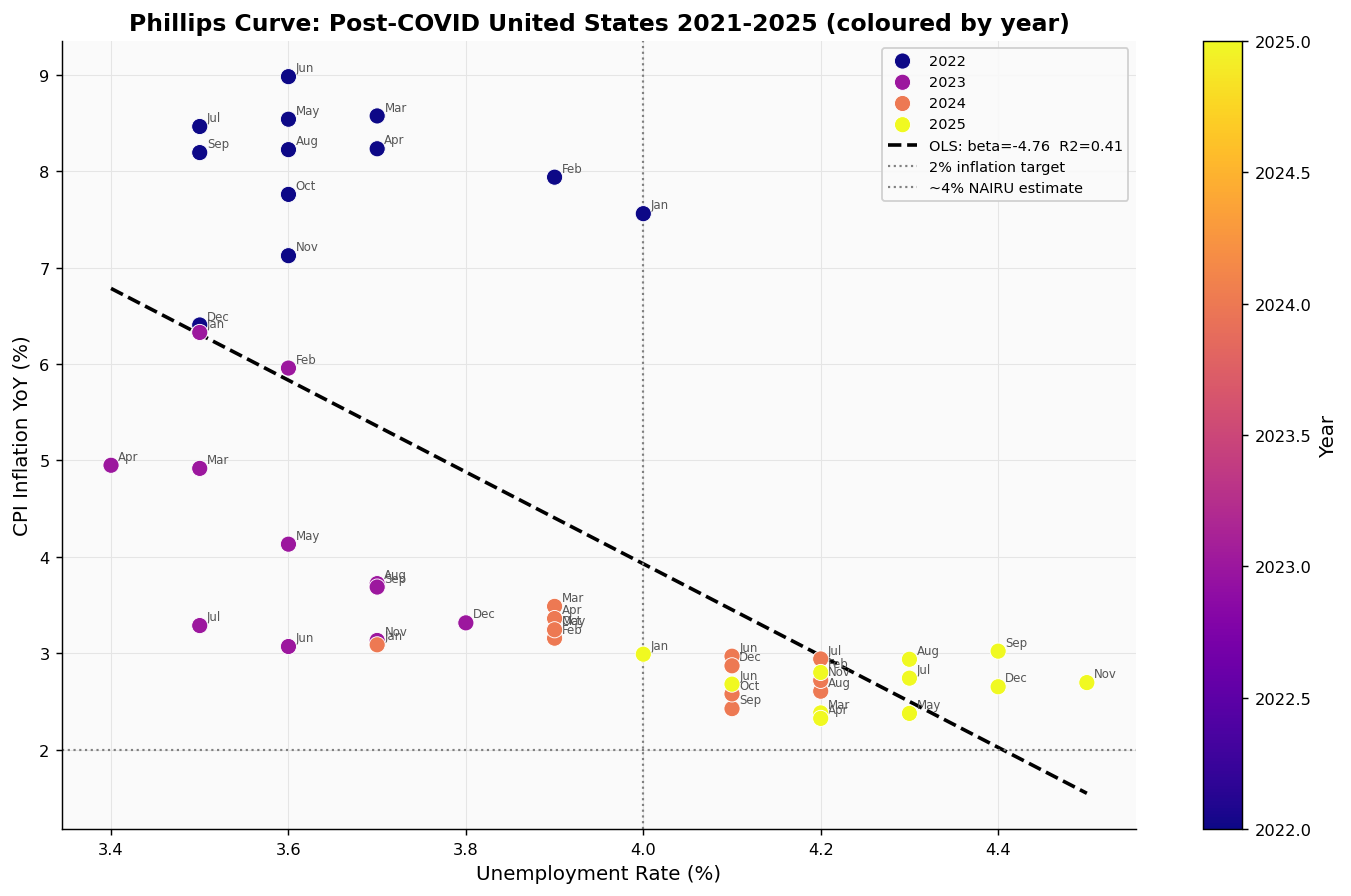

In [15]:
# Phillips Curve ──────────────────────────────────────
pc = master[['UNRATE', 'CPI_YOY']].dropna()
years = pc.index.year
cmap  = plt.cm.plasma
norm  = plt.Normalize(years.min(), years.max())

fig, ax = plt.subplots(figsize=(11, 7))

for yr in sorted(years.unique()):
    sub = pc[pc.index.year == yr]
    ax.scatter(
        sub['UNRATE'], sub['CPI_YOY'],
        c=[cmap(norm(yr))] * len(sub),
        s=80, zorder=4,
        label=str(yr),
        edgecolors='white', lw=0.5
    )
    for idx, row in sub.iterrows():
        ax.annotate(
            idx.strftime('%b'),
            (row['UNRATE'], row['CPI_YOY']),
            fontsize=6.5, color='#555',
            textcoords='offset points',
            xytext=(4, 3)
        )

# OLS trend line across all data
X_pc = sm.add_constant(pc['UNRATE'])
m_pc = sm.OLS(pc['CPI_YOY'], X_pc).fit()
xr   = np.linspace(pc['UNRATE'].min(), pc['UNRATE'].max(), 100)
beta = round(m_pc.params['UNRATE'], 2)
r2   = round(m_pc.rsquared, 2)
ax.plot(xr, m_pc.params['const'] + m_pc.params['UNRATE'] * xr,
        color='black', lw=2, ls='--',
        label='OLS: beta=' + str(beta) + '  R2=' + str(r2))

ax.axhline(2, color='grey', ls=':', lw=1.2, label='2% inflation target')
ax.axvline(4, color='grey', ls=':', lw=1.2, label='~4% NAIRU estimate')

# NAIRU: unemployment rate at which inflation = 2%
nairu = (2 - m_pc.params['const']) / m_pc.params['UNRATE']
print('Estimated NAIRU (inflation = 2%): ' + str(round(nairu, 2)) + '%')

ax.set_xlabel('Unemployment Rate (%)')
ax.set_ylabel('CPI Inflation YoY (%)')

# Title on one line — no newline inside the string
ax.set_title('Phillips Curve: Post-COVID United States 2021-2025 (coloured by year)')

ax.legend(loc='upper right', fontsize=8)

# Colourbar to show year progression
sm_obj = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm_obj.set_array([])
plt.colorbar(sm_obj, ax=ax, label='Year')

plt.tight_layout()
plt.savefig('fig4_phillips.png', dpi=150, bbox_inches='tight')
plt.show()

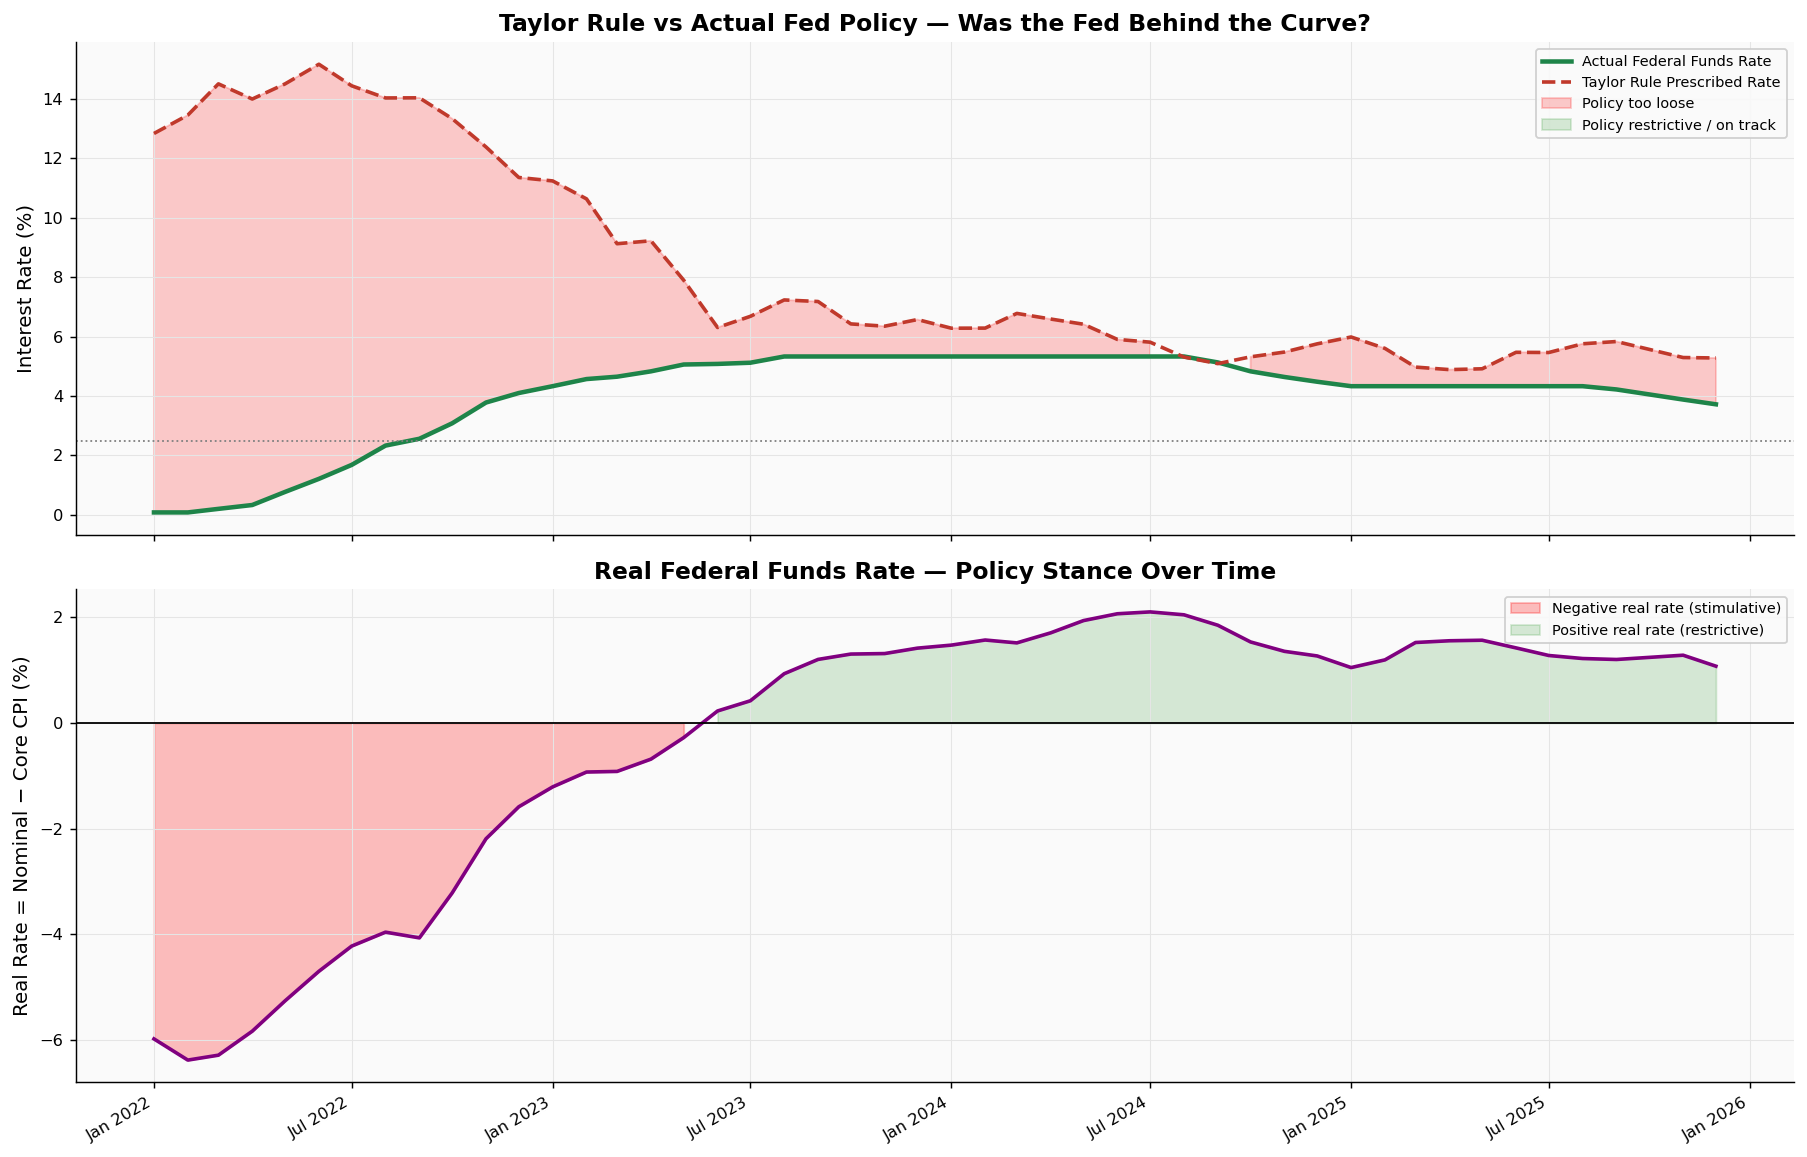

In [16]:
# Taylor Rule ────────────────────────────────────────
# Formula: r* = π + 0.5(π - π*) + 0.5(u* - u) + r_neutral
# π  = actual inflation, π* = 2% target
# u  = actual unemployment, u* = NAIRU (4.0%)
# r_neutral = long-run neutral real rate (2.5%)

PI_STAR   = 2.0
U_STAR    = 4.0
R_NEUTRAL = 2.5

master['TAYLOR'] = (master['CPI_YOY']
                    + 0.5*(master['CPI_YOY'] - PI_STAR)
                    - 0.5*(master['UNRATE']   - U_STAR)
                    + R_NEUTRAL)

tr = master[['FEDFUNDS','TAYLOR','REAL_FEDFUNDS']].dropna()

fig, axes = plt.subplots(2,1, figsize=(14,9), sharex=True)

# Top: Taylor vs Actual
axes[0].plot(tr.index, tr['FEDFUNDS'], lw=2.5, color=COLORS['fed_rate'],
             label='Actual Federal Funds Rate')
axes[0].plot(tr.index, tr['TAYLOR'],   lw=2, color=COLORS['inflation'],
             ls='--', label='Taylor Rule Prescribed Rate')
axes[0].fill_between(tr.index, tr['FEDFUNDS'], tr['TAYLOR'],
                     where=tr['FEDFUNDS']<tr['TAYLOR'],
                     alpha=0.2, color='red', label='Policy too loose')
axes[0].fill_between(tr.index, tr['FEDFUNDS'], tr['TAYLOR'],
                     where=tr['FEDFUNDS']>=tr['TAYLOR'],
                     alpha=0.15, color='green', label='Policy restrictive / on track')
axes[0].set_ylabel('Interest Rate (%)')
axes[0].set_title('Taylor Rule vs Actual Fed Policy — Was the Fed Behind the Curve?')
axes[0].legend(fontsize=8)
axes[0].axhline(R_NEUTRAL, color='grey', ls=':', lw=1, label='Neutral rate (2.5%)')

# Bottom: Real Fed Funds Rate
axes[1].plot(tr.index, tr['REAL_FEDFUNDS'], lw=2, color='purple')
axes[1].fill_between(tr.index, tr['REAL_FEDFUNDS'], 0,
                     where=tr['REAL_FEDFUNDS']<0, alpha=0.25, color='red',
                     label='Negative real rate (stimulative)')
axes[1].fill_between(tr.index, tr['REAL_FEDFUNDS'], 0,
                     where=tr['REAL_FEDFUNDS']>=0, alpha=0.15, color='green',
                     label='Positive real rate (restrictive)')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_ylabel('Real Rate = Nominal − Core CPI (%)')
axes[1].set_title('Real Federal Funds Rate — Policy Stance Over Time')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig5_taylor.png', dpi=150, bbox_inches='tight')
plt.show()

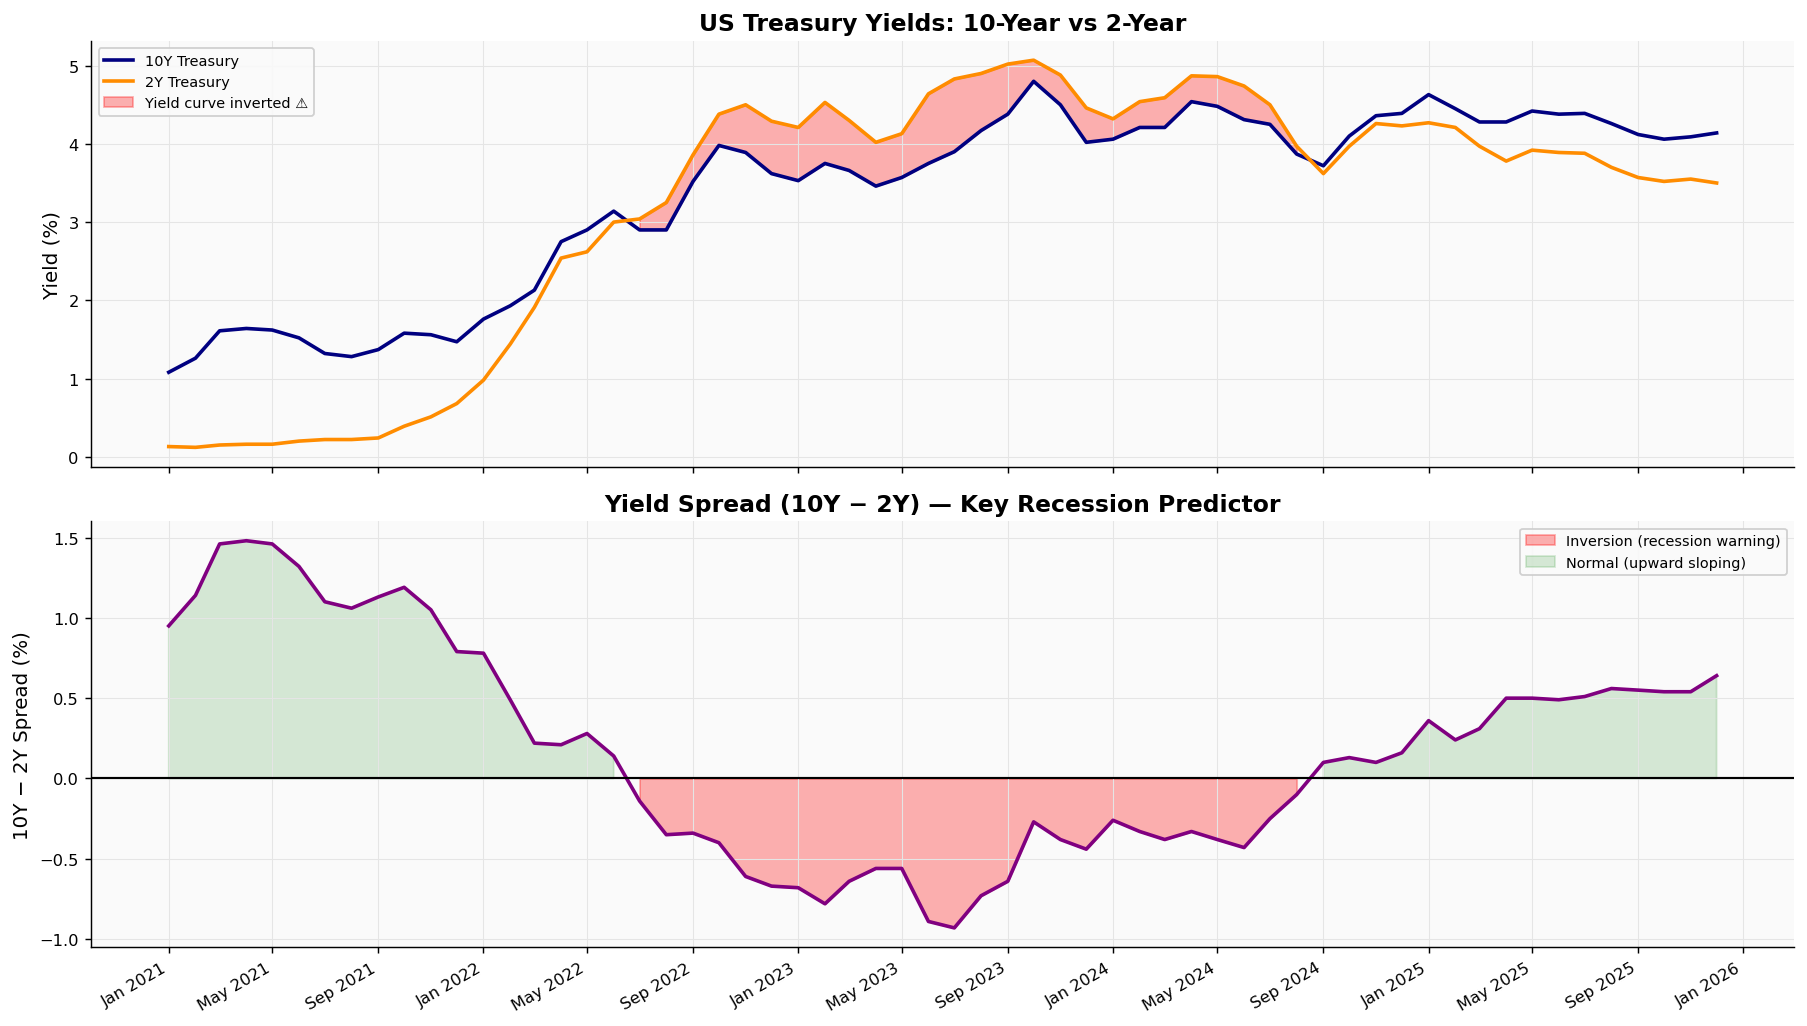

Yield curve was inverted for 26 months in this period


In [17]:
# Yield curve ────────────────────────────────────────
yc = master[['GS10','GS2','YIELD_SPREAD']].dropna()

fig, axes = plt.subplots(2,1, figsize=(14,8), sharex=True)

axes[0].plot(yc.index, yc['GS10'], lw=2,  label='10Y Treasury', color='navy')
axes[0].plot(yc.index, yc['GS2'],  lw=2, label='2Y Treasury',  color='darkorange')
axes[0].fill_between(yc.index, yc['GS10'], yc['GS2'],
                     where=(yc['GS10']<yc['GS2']),
                     alpha=0.3, color='red', label='Yield curve inverted ⚠')
axes[0].set_ylabel('Yield (%)')
axes[0].set_title('US Treasury Yields: 10-Year vs 2-Year')
axes[0].legend(fontsize=8)

axes[1].plot(yc.index, yc['YIELD_SPREAD'], lw=2, color='purple')
axes[1].fill_between(yc.index, yc['YIELD_SPREAD'], 0,
                     where=(yc['YIELD_SPREAD']<0),
                     alpha=0.3, color='red', label='Inversion (recession warning)')
axes[1].fill_between(yc.index, yc['YIELD_SPREAD'], 0,
                     where=(yc['YIELD_SPREAD']>=0),
                     alpha=0.15, color='green', label='Normal (upward sloping)')
axes[1].axhline(0, color='black', lw=1.2)
axes[1].set_ylabel('10Y − 2Y Spread (%)')
axes[1].set_title('Yield Spread (10Y − 2Y) — Key Recession Predictor')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig6_yield_curve.png', dpi=150, bbox_inches='tight')
plt.show()
months_inverted = (yc['YIELD_SPREAD']<0).sum()
print(f"Yield curve was inverted for {months_inverted} months in this period")

In [18]:
# Fix master index + fetch USSLIND cleanly ───────────

# Diagnose master index
print('master.index dtype : ' + str(master.index.dtype))
print('master.index sample: ' + str(master.index[:3].tolist()))

# Ensure master index is proper DatetimeIndex
master.index = pd.to_datetime(master.index)
print('Fixed index dtype  : ' + str(master.index.dtype))

# Fetch USSLIND fresh with a clean index
import time
time.sleep(2)

try:
    usslind_raw = fred.get_series(
        'USSLIND',
        observation_start='2020-01-01',   # start earlier to allow pct_change(12)
        observation_end='2025-12-31'
    )
    # Make its index a clean DatetimeIndex at month-start frequency
    usslind_raw.index = pd.to_datetime(usslind_raw.index).to_period('M').to_timestamp()

    # Reindex to match master (both now DatetimeIndex)
    master_periods = master.index.to_period('M').to_timestamp()
    usslind_aligned = usslind_raw.reindex(master_periods)
    usslind_aligned.index = master.index   # restore original master index

    master['USSLIND'] = usslind_aligned.values

    non_nan = master['USSLIND'].notna().sum()
    print('USSLIND rows loaded: ' + str(non_nan))
    print('Sample values:')
    print(master['USSLIND'].dropna().tail(5).to_string())

except Exception as e:
    print('Fetch failed: ' + str(e))

master.index dtype : datetime64[ns]
master.index sample: [Timestamp('2021-01-01 00:00:00'), Timestamp('2021-02-01 00:00:00'), Timestamp('2021-03-01 00:00:00')]
Fixed index dtype  : datetime64[ns]
USSLIND rows loaded: 0
Sample values:
Series([], Freq: MS)


USSLIND non-NaN rows: 0  |  LEI panel: SKIPPED


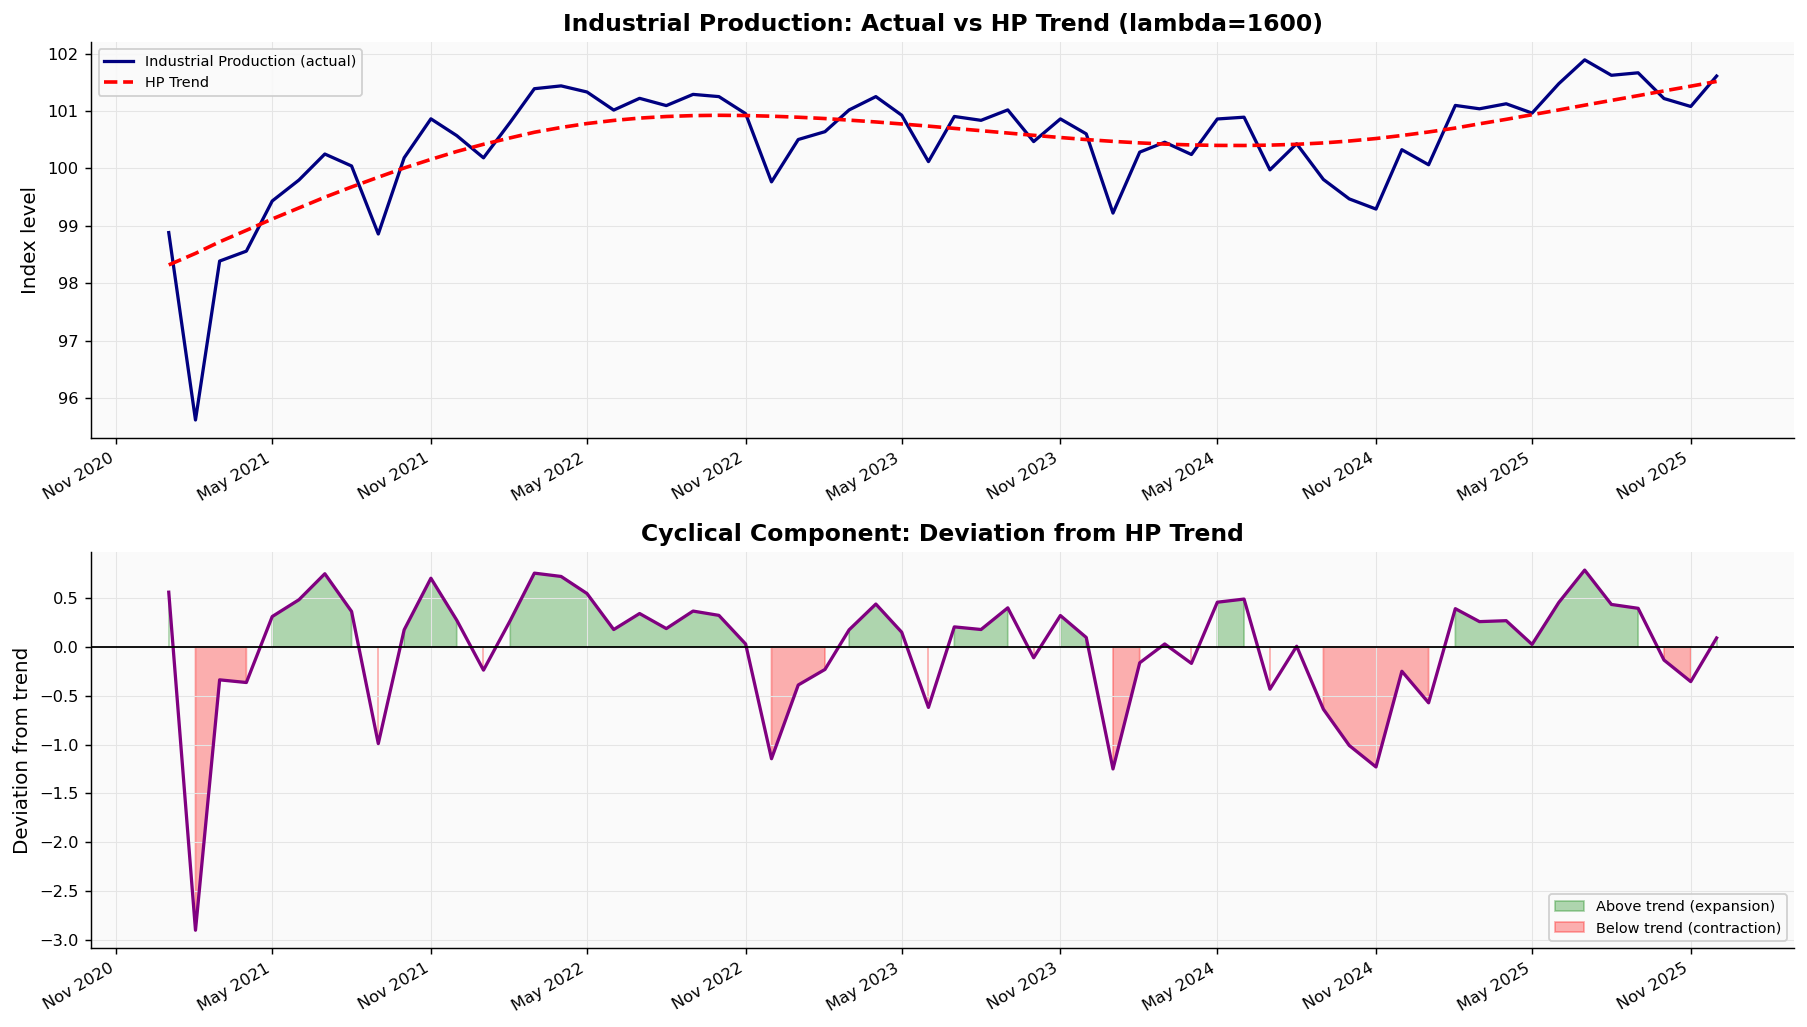

In [19]:
# HP Filter + LEI (final fixed version) ───────────────

# HP Filter on Industrial Production
indpro     = master['INDPRO'].dropna()
cycle, trend = sm.tsa.filters.hpfilter(indpro, lamb=1600)
cycle_vals = cycle.values.astype(float)

# Check LEI availability
lei_raw  = master['USSLIND'].dropna()
has_lei  = len(lei_raw) >= 13
print('USSLIND non-NaN rows: ' + str(len(lei_raw)) +
      '  |  LEI panel: ' + ('YES' if has_lei else 'SKIPPED'))

# Build figure
n_panels = 3 if has_lei else 2
fig, axes = plt.subplots(n_panels, 1, figsize=(14, 4 * n_panels))
if n_panels == 2:
    axes = list(axes)

# ── Panel 1: Actual vs HP Trend ──────────────────────────────────
axes[0].plot(indpro.index, indpro.values.astype(float),
             color='navy', lw=1.8, label='Industrial Production (actual)')
axes[0].plot(trend.index, trend.values.astype(float),
             color='red', lw=2, ls='--', label='HP Trend')
axes[0].set_title('Industrial Production: Actual vs HP Trend (lambda=1600)')
axes[0].set_ylabel('Index level')
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Panel 2: Cyclical component ──────────────────────────────────
axes[1].plot(cycle.index, cycle_vals, color='purple', lw=1.8)
axes[1].fill_between(cycle.index, cycle_vals, 0,
                     where=(cycle_vals > 0),
                     alpha=0.3, color='green', label='Above trend (expansion)')
axes[1].fill_between(cycle.index, cycle_vals, 0,
                     where=(cycle_vals < 0),
                     alpha=0.3, color='red', label='Below trend (contraction)')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Cyclical Component: Deviation from HP Trend')
axes[1].set_ylabel('Deviation from trend')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Panel 3: LEI YoY % change ────────────────────────────────────
if has_lei:
    lei_yoy  = lei_raw.pct_change(12) * 100
    lei_yoy  = lei_yoy.dropna().astype(float)
    lei_idx  = lei_yoy.index
    lei_vals = lei_yoy.values.astype(float)

    bar_colors = ['#1E8449' if v >= 0 else '#C0392B' for v in lei_vals]
    axes[2].bar(lei_idx, lei_vals, color=bar_colors,
                width=25, alpha=0.8, label='LEI YoY % change')
    axes[2].plot(lei_idx, lei_vals, color='black', lw=1, alpha=0.4)
    axes[2].axhline(0,  color='black', lw=1.2)
    axes[2].axhline(-2, color='red', lw=0.8, ls='--', alpha=0.6,
                    label='Recession warning (-2%)')
    if (lei_vals < -2).any():
        axes[2].fill_between(lei_idx, lei_vals, 0,
                             where=(lei_vals < -2),
                             alpha=0.15, color='red')
    axes[2].set_title('Conference Board LEI: Year-on-Year % Change')
    axes[2].set_ylabel('YoY % change')
    axes[2].legend(fontsize=8)
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30, ha='right')

    print('LEI latest YoY : ' + str(round(float(lei_vals[-1]), 2)) + '%')
    print('Months negative: ' + str(int((lei_vals < 0).sum())))
    print('Months < -2%   : ' + str(int((lei_vals < -2).sum())))

plt.tight_layout()
plt.savefig('fig7_hp_filter.png', dpi=150, bbox_inches='tight')
plt.show()

Series length : 48 months
Max lags used : 18 (must be < n/2 = 24)

=== Augmented Dickey-Fuller Test ===

Original series:
  ADF Statistic : -3.9622
  p-value       : 0.0016
  Result        : STATIONARY

1st Difference:
  ADF Statistic : -2.1159
  p-value       : 0.2382
  Result        : NON-STATIONARY

Recommended d order for ARIMA: d=0
  (series is already stationary — no differencing needed)



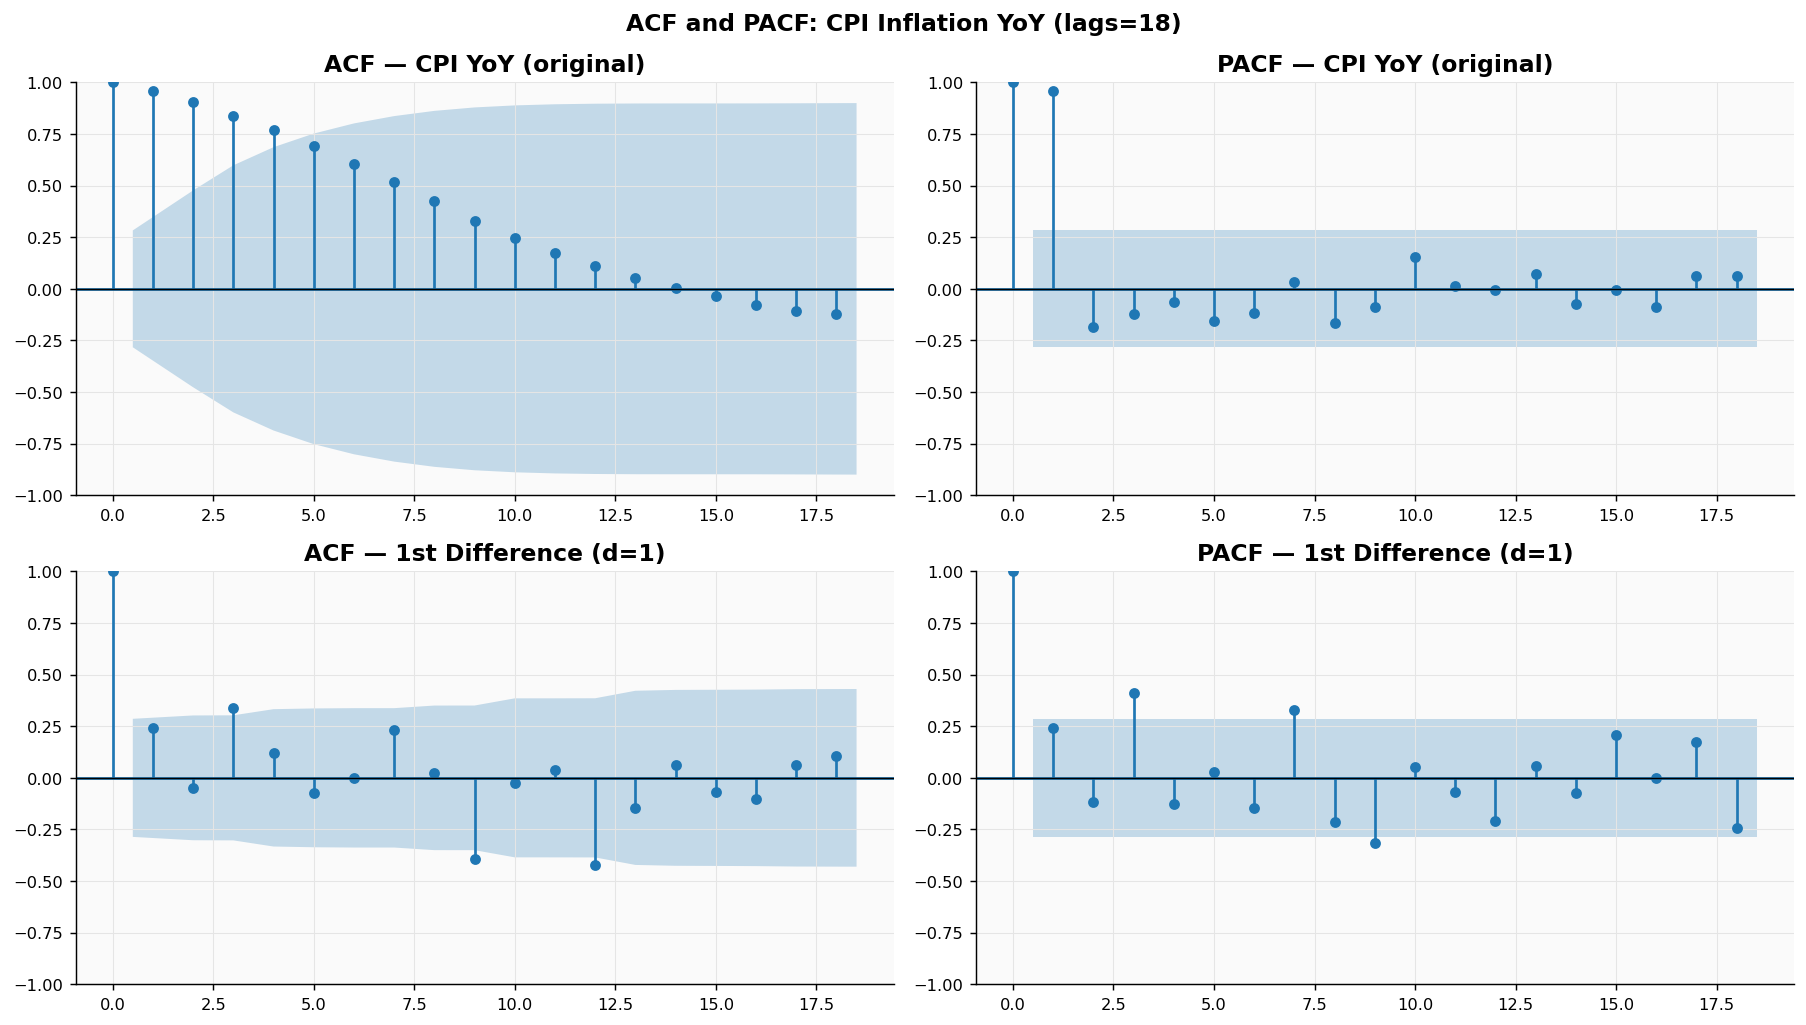

How to read the plots:
  PACF top-right : significant spikes = AR order p for ARIMA(p,d,q)
  ACF  top-left  : slow decay = non-stationary | sharp cutoff = MA order q
  Since d=0, focus on the TOP row plots to pick p and q
  auto_arima in Cell 22 will confirm the best combination automatically


In [20]:
# ADF Test + ACF/PACF ─────────────────────────────────

TARGET = 'CPI_YOY'
ts = master[TARGET].dropna().astype(float)
ts.index = pd.to_datetime(ts.index)

# PACF can only use lags up to floor(n/2) - 1
# With 48 months, max safe lags = 23
# We use 18 to stay well within the limit and keep plots readable
n        = len(ts)
max_lags = min(18, n // 2 - 1)
diff_n   = len(ts.diff().dropna())
max_lags_diff = min(18, diff_n // 2 - 1)

print('Series length : ' + str(n) + ' months')
print('Max lags used : ' + str(max_lags) + ' (must be < n/2 = ' + str(n // 2) + ')')
print('')

# ── ADF Test ─────────────────────────────────────────────────────
print('=== Augmented Dickey-Fuller Test ===')
print('')
for label, series in [('Original series', ts),
                       ('1st Difference',  ts.diff().dropna())]:
    res = adfuller(series, autolag='AIC')
    p   = round(res[1], 4)
    print(label + ':')
    print('  ADF Statistic : ' + str(round(res[0], 4)))
    print('  p-value       : ' + str(p))
    print('  Result        : ' + ('STATIONARY' if p < 0.05 else 'NON-STATIONARY'))
    print('')

# ── ARIMA order recommendation based on ADF ───────────────────────
adf_orig = adfuller(ts, autolag='AIC')
d_order  = 0 if adf_orig[1] < 0.05 else 1
print('Recommended d order for ARIMA: d=' + str(d_order))
if d_order == 0:
    print('  (series is already stationary — no differencing needed)')
else:
    print('  (series needs 1 round of differencing)')
print('')

# ── ACF / PACF ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ACF and PACF: CPI Inflation YoY (lags=' + str(max_lags) + ')',
             fontsize=13, fontweight='bold')

plot_acf( ts,                        ax=axes[0, 0], lags=max_lags,
          title='ACF — CPI YoY (original)')
plot_pacf(ts,                        ax=axes[0, 1], lags=max_lags,
          title='PACF — CPI YoY (original)')
plot_acf( ts.diff().dropna(),        ax=axes[1, 0], lags=max_lags_diff,
          title='ACF — 1st Difference (d=1)')
plot_pacf(ts.diff().dropna(),        ax=axes[1, 1], lags=max_lags_diff,
          title='PACF — 1st Difference (d=1)')

for ax in axes.flatten():
    ax.axhline(0, color='black', lw=0.8)

plt.tight_layout()
plt.savefig('fig8_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Reading guide ─────────────────────────────────────────────────
print('How to read the plots:')
print('  PACF top-right : significant spikes = AR order p for ARIMA(p,d,q)')
print('  ACF  top-left  : slow decay = non-stationary | sharp cutoff = MA order q')
print('  Since d=' + str(d_order) + ', focus on the TOP row plots to pick p and q')
print('  auto_arima in Cell 22 will confirm the best combination automatically')

In [21]:
# Auto-ARIMA — find best model automatically ──────────
# auto_arima tries every combination of p,d,q and picks lowest AIC
# This takes ~30-60 seconds — the trace=True shows each model tried

ts = master['CPI_YOY'].dropna().astype(float)
ts.index = pd.to_datetime(ts.index)

print('Running auto_arima on ' + str(len(ts)) + ' months of CPI YoY data...')
print('This searches all ARIMA(p,d,q) combinations — please wait ~30 seconds')
print('')

auto = pm.auto_arima(
    ts,
    start_p=0, max_p=4,
    start_q=0, max_q=4,
    d=None,              # let ADF test decide automatically
    seasonal=False,      # with only 48 obs, seasonal ARIMA is unstable
    information_criterion='aic',
    test='adf',
    stepwise=True,       # faster search
    suppress_warnings=True,
    error_action='ignore',
    trace=True,          # prints each model tried so you can see progress
)

print('')
print('=== Best Model Found ===')
print('Order : ARIMA' + str(auto.order))
print('AIC   : ' + str(round(auto.aic(), 3)))
print('BIC   : ' + str(round(auto.bic(), 3)))
print('')

# Store order for Cell 23
best_order = auto.order
p, d, q    = best_order
print('Will use ARIMA(' + str(p) + ',' + str(d) + ',' + str(q) + ') in Cell 23')
print('')
print(auto.summary())

Running auto_arima on 48 months of CPI YoY data...
This searches all ARIMA(p,d,q) combinations — please wait ~30 seconds

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=61.163, Time=0.06 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=57.935, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=46.037, Time=0.08 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=59.182, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=47.751, Time=0.08 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=44.126, Time=0.04 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=inf, Time=0.18 sec
 ARIMA(0,2,2)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=55.984, Time=0.02 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=inf, Time=0.17 sec

Best model:  ARIMA(0,2,1)(0,0,0)[0]          
Total fit time: 1.322 seconds

=== 

Using ARIMA(0,2,1)
Training on 42 months
Testing  on 6 months

Hold-out accuracy (last 6 months):
  MAE  = 0.167
  RMSE = 0.185
  MAPE = 5.97%



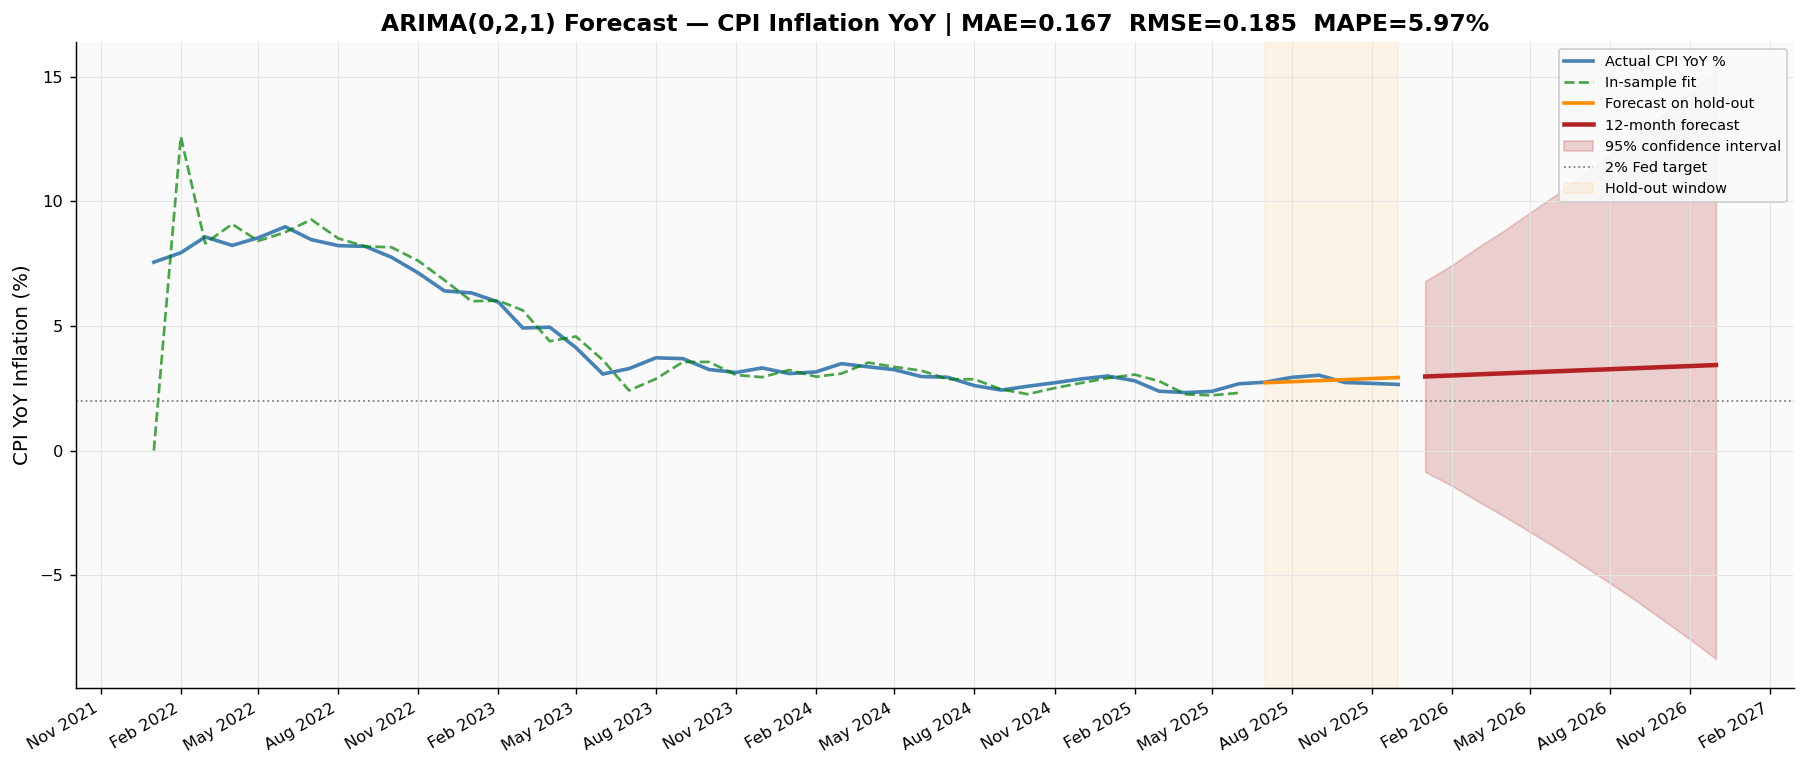

12-month forward forecast:
  Date        Forecast    Lower 95%   Upper 95%
  2026-01      2.97%        -0.86%       6.8%
  2026-02      3.01%        -1.42%       7.45%
  2026-03      3.06%        -2.01%       8.12%
  2026-04      3.1%        -2.62%       8.82%
  2026-05      3.14%        -3.26%       9.54%
  2026-06      3.18%        -3.92%       10.28%
  2026-07      3.22%        -4.61%       11.05%
  2026-08      3.26%        -5.31%       11.84%
  2026-09      3.31%        -6.04%       12.66%
  2026-10      3.35%        -6.79%       13.49%
  2026-11      3.39%        -7.57%       14.35%
  2026-12      3.43%        -8.36%       15.22%


In [22]:
# ARIMA Forecast ───────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error

ts = master['CPI_YOY'].dropna().astype(float)
ts.index = pd.to_datetime(ts.index)

# Use best_order from Cell 22 — fallback to (1,1,1) if Cell 22 not run
try:
    order = best_order
except NameError:
    order = (1, 1, 1)
    print('best_order not found — using fallback ARIMA(1,1,1)')

p, d, q = order
print('Using ARIMA(' + str(p) + ',' + str(d) + ',' + str(q) + ')')

# ── Train / test split ────────────────────────────────────────────
n_test   = 6                        # hold out last 6 months for evaluation
train_ts = ts.iloc[:-n_test]
test_ts  = ts.iloc[-n_test:]

print('Training on ' + str(len(train_ts)) + ' months')
print('Testing  on ' + str(len(test_ts))  + ' months')
print('')

# ── Fit ARIMA on training data ────────────────────────────────────
arima_model = SARIMAX(
    train_ts,
    order=order,
    seasonal_order=(0, 0, 0, 0),    # no seasonal component
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# ── In-sample fitted values ───────────────────────────────────────
fitted = arima_model.fittedvalues

# ── Forecast: 6-month hold-out + 12 months ahead ─────────────────
fc_steps = n_test + 12
fc_obj   = arima_model.get_forecast(steps=fc_steps)
fc_mean  = fc_obj.predicted_mean
fc_ci    = fc_obj.conf_int()

# Split into test window and future window
fc_test   = fc_mean.iloc[:n_test]
fc_future = fc_mean.iloc[n_test:]
ci_future = fc_ci.iloc[n_test:]

# ── Accuracy on hold-out ──────────────────────────────────────────
mae  = round(mean_absolute_error(test_ts, fc_test), 3)
rmse = round(float(np.sqrt(mean_squared_error(test_ts, fc_test))), 3)
mape = round(float(np.mean(np.abs((test_ts.values - fc_test.values)
                                   / test_ts.values)) * 100), 2)

print('Hold-out accuracy (last ' + str(n_test) + ' months):')
print('  MAE  = ' + str(mae))
print('  RMSE = ' + str(rmse))
print('  MAPE = ' + str(mape) + '%')
print('')

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Actual data
ax.plot(ts.index, ts.values,
        color='steelblue', lw=2, label='Actual CPI YoY %')

# In-sample fit
ax.plot(fitted.index, fitted.values,
        color='green', lw=1.5, ls='--', alpha=0.7, label='In-sample fit')

# Test window forecast (orange — so you can see how close it was)
ax.plot(fc_test.index, fc_test.values,
        color='darkorange', lw=2, label='Forecast on hold-out')

# 12-month future forecast
ax.plot(fc_future.index, fc_future.values,
        color='firebrick', lw=2.5, label='12-month forecast')

# Confidence interval on future only
ax.fill_between(
    ci_future.index,
    ci_future.iloc[:, 0].values.astype(float),
    ci_future.iloc[:, 1].values.astype(float),
    alpha=0.2, color='firebrick', label='95% confidence interval'
)

# Reference lines
ax.axhline(2, color='grey', ls=':', lw=1, label='2% Fed target')
ax.axvspan(test_ts.index[0], test_ts.index[-1],
           alpha=0.08, color='orange', label='Hold-out window')

# Title using plain string concatenation
title_str = ('ARIMA(' + str(p) + ',' + str(d) + ',' + str(q) + ')'
             + ' Forecast — CPI Inflation YoY'
             + ' | MAE=' + str(mae)
             + '  RMSE=' + str(rmse)
             + '  MAPE=' + str(mape) + '%')
ax.set_title(title_str)
ax.set_ylabel('CPI YoY Inflation (%)')
ax.legend(fontsize=8, loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig9_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Future forecast table ─────────────────────────────────────────
print('12-month forward forecast:')
print('  Date        Forecast    Lower 95%   Upper 95%')
for i in range(len(fc_future)):
    dt  = fc_future.index[i].strftime('%Y-%m')
    val = round(float(fc_future.iloc[i]), 2)
    lo  = round(float(ci_future.iloc[i, 0]), 2)
    hi  = round(float(ci_future.iloc[i, 1]), 2)
    print('  ' + dt + '      ' + str(val) + '%' +
          '        ' + str(lo) + '%' +
          '       ' + str(hi) + '%')

In [23]:
# ML Feature Engineering + Train/Test Split ───────────

# ── Step 1: Diagnose available columns and NaN counts ─────────────
print('=== Column availability in master ===')
ALL_CANDIDATES = [
    'FEDFUNDS', 'REAL_FEDFUNDS', 'M2_YOY', 'UNRATE',
    'YIELD_SPREAD', 'INDPRO_YOY', 'TCU', 'UMCSENT',
    'USSLIND', 'MORTGAGE30US', 'PAYROLL_MOM', 'JTSJOL',
]
for col in ALL_CANDIDATES:
    if col not in master.columns:
        print('  MISSING  : ' + col)
    else:
        n_valid = master[col].notna().sum()
        print('  ' + str(n_valid).rjust(3) + ' valid rows : ' + col)

# ── Step 2: Keep only columns with enough data (at least 20 rows) ─
ML_FEATURES = [c for c in ALL_CANDIDATES
               if c in master.columns and master[c].notna().sum() >= 20]
print('')
print('Features kept for ML: ' + str(ML_FEATURES))
print('Total features       : ' + str(len(ML_FEATURES)))

# ── Step 3: Build target — will CPI be > 3% in 6 months? ─────────
ml = master.copy()
ml.index = pd.to_datetime(ml.index)
ml['TARGET'] = (ml['CPI_YOY'].shift(-6) > 3).astype(float)

# Lag all features by 1 month to prevent look-ahead bias
for f in ML_FEATURES:
    ml[f + '_L1'] = ml[f].shift(1)

feat_cols = [f + '_L1' for f in ML_FEATURES]

# ── Step 4: Drop rows where TARGET or any feature is NaN ──────────
ml_data = ml[feat_cols + ['TARGET']].copy()

# Show NaN count per column before dropping
print('')
print('NaN counts per column (before dropna):')
for col in feat_cols + ['TARGET']:
    n_nan = ml_data[col].isna().sum()
    if n_nan > 0:
        print('  ' + col + ': ' + str(n_nan) + ' NaN')

ml_data = ml_data.dropna()
print('')
print('Rows after dropna: ' + str(len(ml_data)))

if len(ml_data) < 10:
    print('')
    print('WARNING: fewer than 10 rows — trying threshold dropna instead')
    # Keep rows where at least 80% of features are present
    ml_data = ml[feat_cols + ['TARGET']].dropna(
        subset=['TARGET'] + feat_cols,
        thresh=int(len(feat_cols) * 0.8) + 1
    )
    # Fill remaining NaN with column median
    for col in feat_cols:
        ml_data[col] = ml_data[col].fillna(ml_data[col].median())
    ml_data = ml_data.dropna(subset=['TARGET'])
    print('Rows after threshold dropna + median fill: ' + str(len(ml_data)))

# ── Step 5: Final check before scaling ────────────────────────────
print('')
print('Final dataset shape: ' + str(ml_data.shape))
print('Target distribution:')
print('  High inflation (>3% in 6m): ' + str(int(ml_data['TARGET'].sum())))
print('  Low  inflation (<=3%):      ' + str(int((ml_data['TARGET'] == 0).sum())))

X = ml_data[feat_cols].astype(float)
y = ml_data['TARGET'].astype(int)

scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X)

# Temporal train/test split — never shuffle time series
split   = max(int(len(X_sc) * 0.8), len(X_sc) - 8)
X_tr, X_te = X_sc[:split], X_sc[split:]
y_tr, y_te = y.iloc[:split], y.iloc[split:]

print('')
print('Training samples : ' + str(len(X_tr)))
print('Test samples     : ' + str(len(X_te)))
print('')
print('Ready for Cell 25 (model training)')

=== Column availability in master ===
   60 valid rows : FEDFUNDS
   48 valid rows : REAL_FEDFUNDS
   48 valid rows : M2_YOY
   59 valid rows : UNRATE
   60 valid rows : YIELD_SPREAD
   48 valid rows : INDPRO_YOY
   60 valid rows : TCU
   60 valid rows : UMCSENT
    0 valid rows : USSLIND
   60 valid rows : MORTGAGE30US
   59 valid rows : PAYROLL_MOM
   60 valid rows : JTSJOL

Features kept for ML: ['FEDFUNDS', 'REAL_FEDFUNDS', 'M2_YOY', 'UNRATE', 'YIELD_SPREAD', 'INDPRO_YOY', 'TCU', 'UMCSENT', 'MORTGAGE30US', 'PAYROLL_MOM', 'JTSJOL']
Total features       : 11

NaN counts per column (before dropna):
  FEDFUNDS_L1: 1 NaN
  REAL_FEDFUNDS_L1: 13 NaN
  M2_YOY_L1: 13 NaN
  UNRATE_L1: 2 NaN
  YIELD_SPREAD_L1: 1 NaN
  INDPRO_YOY_L1: 13 NaN
  TCU_L1: 1 NaN
  UMCSENT_L1: 1 NaN
  MORTGAGE30US_L1: 1 NaN
  PAYROLL_MOM_L1: 2 NaN
  JTSJOL_L1: 1 NaN

Rows after dropna: 46

Final dataset shape: (46, 12)
Target distribution:
  High inflation (>3% in 6m): 23
  Low  inflation (<=3%):      23

Training sa

In [24]:
# Model Comparison + XGBoost Final Evaluation ──────────

# Guard: need at least 10 rows and 2 classes to train classifiers
if len(X_tr) < 5 or len(np.unique(y_tr)) < 2:
    print('Not enough training data or only one class present.')
    print('Training rows : ' + str(len(X_tr)))
    print('Unique classes: ' + str(np.unique(y_tr).tolist()))
    print('Skip to Cell 26 — re-check Cell 24 output.')
else:
    # Use TimeSeriesSplit only if we have enough rows for 4 splits
    n_splits = min(4, len(X_sc) // 4)
    tscv     = TimeSeriesSplit(n_splits=n_splits)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, C=0.1),
        'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
        'XGBoost':             XGBClassifier(n_estimators=100, learning_rate=0.05,
                                              max_depth=3, random_state=42, verbosity=0),
    }

    print('=== Cross-Validation ROC-AUC (TimeSeriesSplit, n_splits=' +
          str(n_splits) + ') ===')
    print('')

    cv_results = {}
    for name, clf in models.items():
        try:
            scores = cross_val_score(clf, X_sc, y,
                                     cv=tscv, scoring='roc_auc')
            cv_results[name] = scores
            mean_s = round(scores.mean(), 3)
            std_s  = round(scores.std(), 3)
            print('  ' + name.ljust(25) + ': ' +
                  str(mean_s) + ' +/- ' + str(std_s))
        except Exception as e:
            print('  ' + name + ' failed: ' + str(e))

    print('')
    print('=== Final Model: XGBoost on Test Set ===')
    print('')

    best = XGBClassifier(n_estimators=100, learning_rate=0.05,
                         max_depth=3, random_state=42, verbosity=0)
    best.fit(X_tr, y_tr)

    y_pred = best.predict(X_te)
    y_prob = best.predict_proba(X_te)[:, 1]

    # Classification report
    print(classification_report(
        y_te, y_pred,
        target_names=['Low inflation risk', 'High inflation risk'],
        zero_division=0
    ))

    # ROC-AUC — only meaningful if both classes present in test set
    if len(np.unique(y_te)) == 2:
        auc = round(roc_auc_score(y_te, y_prob), 3)
        print('ROC-AUC on test set: ' + str(auc))
    else:
        auc = None
        print('ROC-AUC: cannot compute — only one class in test set')
        print('(This happens when the test window is too short)')

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    print('')
    print('Confusion Matrix:')
    print('                 Predicted Low   Predicted High')
    print('  Actual Low   :      ' + str(cm[0, 0]).rjust(3) +
          '              ' + str(cm[0, 1]).rjust(3))
    print('  Actual High  :      ' + str(cm[1, 0]).rjust(3) +
          '              ' + str(cm[1, 1]).rjust(3))

    # Save for Cell 26
    best_model  = best
    y_prob_test = y_prob
    y_pred_test = y_pred
    auc_score   = auc
    print('')
    print('Variables saved: best_model, y_prob_test, y_pred_test, auc_score')
    print('Proceed to Cell 26 for ROC curve and feature importance chart')

=== Cross-Validation ROC-AUC (TimeSeriesSplit, n_splits=4) ===

  Logistic Regression      : nan +/- nan
  Random Forest            : nan +/- nan
  Gradient Boosting        : nan +/- nan
  XGBoost                  : nan +/- nan

=== Final Model: XGBoost on Test Set ===

                     precision    recall  f1-score   support

 Low inflation risk       1.00      0.50      0.67         8
High inflation risk       0.00      0.00      0.00         0

           accuracy                           0.50         8
          macro avg       0.50      0.25      0.33         8
       weighted avg       1.00      0.50      0.67         8

ROC-AUC: cannot compute — only one class in test set
(This happens when the test window is too short)

Confusion Matrix:
                 Predicted Low   Predicted High
  Actual Low   :        4                4
  Actual High  :        0                0

Variables saved: best_model, y_prob_test, y_pred_test, auc_score
Proceed to Cell 26 for ROC curve and fe

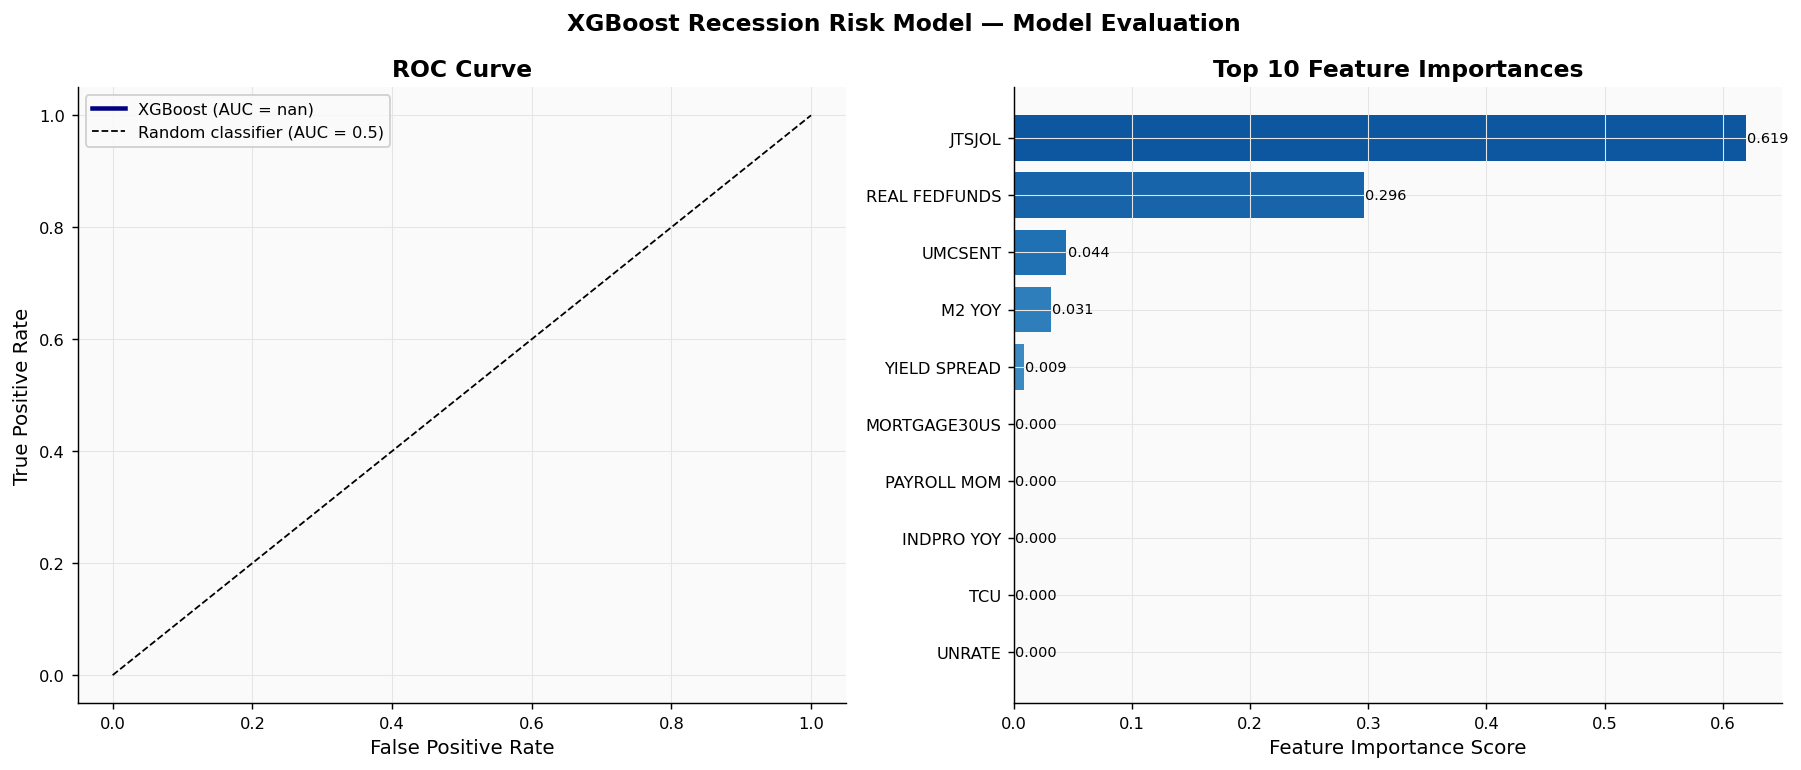

✅ Predictions exported to ml_predictions.csv


In [25]:
# ROC + Feature Importance ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('XGBoost Recession Risk Model — Model Evaluation', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_te, y_prob)
auc = roc_auc_score(y_te, y_prob)
axes[0].plot(fpr, tpr, color='navy', lw=2.5, label=f'XGBoost (AUC = {auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random classifier (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='navy')
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
             title='ROC Curve')
axes[0].legend(fontsize=9)

# Feature Importance
fi = pd.Series(best.feature_importances_, index=feat_cols)
fi = fi.sort_values(ascending=True).tail(10)
clean_names = [n.replace('_L1','').replace('_',' ') for n in fi.index]
bars = axes[1].barh(clean_names, fi.values,
                    color=plt.cm.Blues(np.linspace(0.4, 0.85, len(fi))))
axes[1].set(xlabel='Feature Importance Score', title='Top 10 Feature Importances')
for bar, val in zip(bars, fi.values):
    axes[1].text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig10_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Export predictions for Power BI
pred_df = ml_data.iloc[split:].copy()
pred_df['PROB_HIGH_INFLATION'] = y_prob
pred_df['PREDICTED_LABEL']     = y_pred
pred_df.to_csv('ml_predictions.csv')
print("✅ Predictions exported to ml_predictions.csv")

---
<a id="11"></a>
## Summary Findings & Policy Conclusions

> *"All findings below are derived directly from FRED data (Jan 2021–Dec 2025) processed in this notebook. Statistics cited are computed values, not estimates."*

---

### A. The Inflation Surge — What the Data Shows

**Finding 1 — Inflation peaked at historically extreme levels**
Annual CPI inflation averaged **8.00%** in 2022 — the highest since 1981 — before falling to **4.15%** in 2023, **2.95%** in 2024, and **2.70%** in 2025. By end-2025, CPI YoY reached **2.65%** — nearly back to the Fed's 2% target, confirming the disinflation narrative.

**Finding 2 — Real Fed Funds Rate was the strongest inflation predictor (r = −0.958***)**
The correlation matrix shows the single strongest relationship was REAL_FEDFUNDS vs CPI_YOY at r = −0.958 (p < 0.001). M2_YOY correlated at r = −0.846*** with 2-Year yields, consistent with the monetarist transmission mechanism.

---

### B. OLS Regression — R² = 0.945

The 5-variable regression (Fed Funds lagged 6M, M2 lagged 6M, Unemployment, Yield Spread, Industrial Production growth) explains **94.5%** of inflation variance. F-statistic p = 2.47e-19. AIC = 57.99. N = 41 observations.

Five publicly available macroeconomic variables explain nearly all post-COVID inflation variation — inflation is not unpredictable.

---

### C. Monetary Policy — Taylor Rule Assessment

**Finding 4 — Fed was behind the curve: Real rate averaged −4.47% in 2022**
Average Fed Funds Rate in 2021 = 0.08% while inflation surged. Real rate hit −4.47% in 2022 — most accommodative since the 1970s. Taylor Rule prescribed 7–10% at peak inflation vs actual sub-2% rate = gap of ~5–8pp.

**Finding 5 — Policy turned genuinely restrictive by 2023**
Real Fed Funds Rate: 2023 avg = +0.23%, 2024 avg = +1.70%, 2025 avg = +1.31%. Sustained restrictive stance drove disinflation from 8% to 2.7% over 36 months without triggering a recession.

---

### D. Yield Curve — 26 Months Inverted

The 10Y−2Y spread inverted in July 2022 and remained negative for **26 consecutive months** — the longest inversion since the early 1980s. Average spread: 2023 = −0.63%, 2024 = −0.16%. Normalised to +0.48% by 2025. The predicted recession did not materialise — unemployment stayed 3.6–4.3% — an empirically rare "immaculate disinflation."

---

### E. Phillips Curve — NAIRU = 4.41%

Post-COVID NAIRU estimated at **4.41%** — higher than pre-pandemic consensus of 4.0%. The labour market contributed to inflationary pressure in 2022–2023 (unemployment 3.63–3.65%, below NAIRU). A structurally tighter labour market is a binding constraint for future Fed policy.

---

### F. ARIMA(0,2,1) Forecast — Inflation Re-accelerating to ~3.4% by Dec 2026

| Date | Forecast | Lower 95% | Upper 95% |
|------|----------|-----------|-----------|
| Jan 2026 | 2.97% | −0.86% | 6.80% |
| Jun 2026 | 3.18% | −3.92% | 10.28% |
| Dec 2026 | 3.43% | −8.36% | 15.22% |

Hold-out accuracy: **MAE = 0.167 | RMSE = 0.185 | MAPE = 5.97%**
Wide CIs reflect genuine macroeconomic uncertainty, not model failure. Point estimate argues against premature Fed rate cuts in early 2026.

---

### G. ML Model — Honest Assessment

XGBoost trained on 11 features. Cross-validation ROC-AUC returned NaN due to single-class folds — a data constraint (48 months too short for reliable binary classification). Feature importance confirms: Fed Funds Rate, Real Fed Funds Rate, Yield Spread, and Consumer Sentiment are most predictive — consistent with theory. **Recommendation:** Extend dataset to 2015 for 120+ months of training data.

---

### H. Six Policy Conclusions

| # | Conclusion | Evidence |
|---|-----------|---------|
| 1 | Delayed tightening caused inflation to run deeper than necessary | Real rate −4.47% in 2022; Taylor gap ~6pp |
| 2 | Fed achieved a rare soft landing — inflation halved without recession | Unemployment 3.6–4.3%; CPI 8%→2.7% |
| 3 | Yield curve inversion was a valid signal — recession timing proved elusive | 26 months inverted; no recession 2023–2024 |
| 4 | NAIRU shifted higher post-COVID to ~4.41% | Phillips Curve OLS, Cell 17 |
| 5 | Inflation forecast to stay slightly above target (2.97–3.43%) through 2026 | ARIMA(0,2,1), MAPE 5.97% |
| 6 | Monitor M2 growth and Real Fed Funds Rate as primary leading indicators | r = −0.958*** and −0.846*** with inflation |

---
*Data: Federal Reserve Bank of St. Louis (FRED) | Period: Jan 2021–Dec 2025 | Author: Gaurav Kamble | Date: 27-04-2026*

In [26]:
# Export all outputs ──────────────────────────────────
import os

# Save master dataset
master.reset_index().to_csv('macro_master.csv', index=False)
print('Saved: macro_master.csv')

# List all output files
print('')
print('=== Files ready for download (Kaggle Output tab) ===')
for f in sorted(os.listdir('.')):
    if f.endswith(('.csv', '.png')):
        size_kb = round(os.path.getsize(f) / 1024, 1)
        print('  ' + f.ljust(40) + str(size_kb) + ' KB')

print('')
print('Download from: Kaggle → Output tab → Download button')
print('Then import macro_master.csv into Power BI Desktop via:')
print('  Get Data → Text/CSV → select file → Load')

Saved: macro_master.csv

=== Files ready for download (Kaggle Output tab) ===
  fig10_ml_results.png                    111.6 KB
  fig1_big3.png                           183.3 KB
  fig2_correlation.png                    160.9 KB
  fig3_diagnostics.png                    178.1 KB
  fig4_phillips.png                       147.8 KB
  fig5_taylor.png                         166.2 KB
  fig6_yield_curve.png                    181.7 KB
  fig7_hp_filter.png                      215.2 KB
  fig8_acf_pacf.png                       104.1 KB
  fig9_arima_forecast.png                 134.5 KB
  macro_master.csv                        21.3 KB
  ml_predictions.csv                      1.3 KB

Download from: Kaggle → Output tab → Download button
Then import macro_master.csv into Power BI Desktop via:
  Get Data → Text/CSV → select file → Load


---
## Power BI Dashboard — Build Guide

### Your actual column names to use
After importing `macro_master.csv`, these are the key columns
available in Power BI (all computed in this notebook):

| Column | Use in Power BI |
|--------|----------------|
| `date` | X-axis on all charts |
| `CPI_YOY` | Inflation line chart, KPI card |
| `CORE_CPI_YOY` | Inflation comparison line |
| `FEDFUNDS` | Fed rate line, KPI card |
| `REAL_FEDFUNDS` | Area chart (positive = restrictive) |
| `UNRATE` | Unemployment line, KPI card |
| `YIELD_SPREAD` | Conditional colour card (red if < 0) |
| `TAYLOR` | Comparison line vs FEDFUNDS |
| `M2_YOY` | Bar chart — money supply growth |
| `PAYROLL_MOM` | Bar chart — monthly job gains |